In [11]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
from scipy import sparse
import scanpy as sc
import matplotlib.pyplot as plt
import os
import rpy2.robjects as ro
import shutil
import seaborn as sns  

from dotenv import load_dotenv; load_dotenv()

from utils import preprocessing
from utils import DEG

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# ATTENTION: need for perpty of running jupternotbook
%matplotlib inline

PARALLEL_NEBULA_SCRIPT_PATH = os.getenv("PARALLEL_NEBULA_SCRIPT")

TISSUE = "DFC" # Striatum, DFC,SN
TYPE_DEG = "PCA_nebula" #PCA_nebula, baseline_nebula. gradient_score_nebula

if TISSUE == "Striatum":
    ADATA_PATH = f"/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/adatas/{TISSUE}/{TISSUE}_combined_QC_mmc_ct-cured_zoned.h5ad"
elif (TISSUE == "DFC") | (TISSUE == "SN"):
    # no zones
    ADATA_PATH = f"/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/adatas/{TISSUE}/{TISSUE}_combined_QC_mmc_ct-cured.h5ad"

# name of cell tyoe vauble annotaton to use in this analsys
CT_FOR_DEG_VARIABLE = "ct_for_deg" #"Group_name",  "spn_type"
# name of Sample varibale
SAMPLE_VARIABLE = "donor_id"
# variable to test if differtially epxresseda
CONTRAST_VARIABLE = "condition"
# Level of contrat varibale to use as baseline
CONTRAST_BASELINE = "Control"
# Level of contrat varibale to use as stimulated
CONTRAST_STIM = "XDP"

# Covariates to use for stat test
COVARIATES_FOR_DEG = ["age_of_death", "sex", "pct_counts_mt", "frac_intronic", "cohort",
                     #f"age_of_death:{CONTRAST_VARIABLE}"
                      ]
# libraru size col for  enbula
LIBRARY_SIZE_COL = "total_counts"

# # mitluple etst correction pvalue thr
# ALPHA_MULTIPLE_TEST = 0.05
# LOGFC_THR=0.1
# PVAL_THR=0.05

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Read adata

In [12]:
print("Loading adata... tissue:", TISSUE, "type of DEG:", TYPE_DEG)
adata = sc.read_h5ad(ADATA_PATH)#, backed="r")
adata.obs.columns


###########################
#ATTENTION: use genenames for DEG
adata.var.index = adata.var["gene_symbol"]
###########################

###########################
#ATTENTION: remove "bad cell" ypes
adata = adata[~adata.obs["ct_for_deg"].str.startswith("-"), :].copy()
###########################

###########################
#ATTENTION: be sure cell types have no space
adata.obs[CT_FOR_DEG_VARIABLE] = adata.obs[CT_FOR_DEG_VARIABLE].str.replace(" ", "_")
###########################

###########################
#ATTENTION: remove bad quality samples
adata = adata[~adata.obs[CONTRAST_VARIABLE].isna()]
###########################

Loading adata... tissue: DFC type of DEG: PCA_nebula


In [ ]:
# RUN_ON_ZONES = False # if False, will run on ct

# if RUN_ON_ZONES:

#     ZONE_CT = "Astrocyte" #Astrocyte, Matrix_D1

#     # Each cell type has a better zonation level
#     if ZONE_CT in ["Matrix_D1", "Matrix_D2"]:
#         ZONE_VARIABLE = "zone_6" 
#     if ZONE_CT in ["Patch_D1", "Patch_D2", "eMSN_D1D2", "Astrocyte"]:
#         ZONE_VARIABLE = "zone_4"

#     adata = adata[
#         (adata.obs["ct_for_deg"] == ZONE_CT) & # only QC cells tat are matrix
#         (adata.obs[ZONE_VARIABLE].notna()) # only cells with zone annotation
#     ].to_memory().copy()
    
#     # chnage zone to be treated as ct
#     CT_FOR_DEG_VARIABLE = ZONE_VARIABLE

#     print(adata)
#     print(adata.obs.groupby([ZONE_VARIABLE, CONTRAST_VARIABLE]).size())

# Define gradient genes

In [4]:
GRAD_THR=0.1

df_grad = pd.read_csv("/home/gdallagl/myworkdir/XDP/utils/dorsal_ventral_gradient/exp_by_spline_combined.csv")

grad_genes = df_grad[
    (np.abs(df_grad.mean_spearman)>= GRAD_THR) & 
    (df_grad.combined_p <= 0.05) &
    (df_grad.mean_spearman.notna()) 
    ]["gene"].tolist()
print(len(grad_genes))

df_grad["is_gradient_gene"] = df_grad["gene"].isin(grad_genes)
print(df_grad["is_gradient_gene"].sum())
df_grad = df_grad.set_index("gene")[["mean_spearman", "is_gradient_gene"]]
df_grad

1241
1241


,mean_spearman,is_gradient_gene
gene,,
A1BG,-0.002360,False
A1BG-AS1,-0.007881,False
A1CF,0.007398,False
A2M,-0.002144,False
A2M-AS1,-0.000389,False
...,...,...
ENSG00000277836,NaN,False
ENSG00000278633,NaN,False
ENSG00000276017,-0.008289,False


# Calculate gradient score

In [ ]:
# def calc_gradient_score(adata, df_grad, csv_save_path, col_corr="mean_spearman"):

#     print("ATTENTION: adata.X must be raw.")
#     print("ATTENTION: df_grad must have ONLY gradient genes and gene names as index.")

#     # Normalise
#     sc.pp.normalize_total(adata, target_sum=1e4)
#     sc.pp.log1p(adata)

#     # Calculate collim genes
#     common_genes = adata.var_names.intersection(df_grad.index)

#     # Subset to common genes
#     import scipy.sparse as sp
#     df_grad = df_grad.loc[common_genes]
#     X_grad_genes = adata[:, common_genes].X  # (n_cells × n_genes)
#     X_grad_genes = X_grad_genes.toarray() if sp.issparse(X_grad_genes) else np.asarray(X_grad_genes)


#     # calculate score
#     # more dorsal genes --> higher score
#     adata.obs["gradient_score"] = - X_grad_genes @ df_grad[col_corr].values

#     assert not adata.obs['gradient_score'].isna().any(), "Some cells have no gradient scores!"

#     # save df
#     df_scores = adata.obs[["gradient_score"]]
#     df_scores.to_csv(csv_save_path)


In [ ]:
# # define genes for grad

# save_csv_path = f"{os.path.dirname(ADATA_PATH)}/gradient_scores.csv"

# if not os.path.exists(save_csv_path):

#     adata.X = adata.layers["counts"].copy()  # use raw counts for score calculation
#     df_grad_significant = df_grad[df_grad["is_gradient_gene"]]
#     calc_gradient_score(adata, df_grad_significant, save_csv_path)

# else:
#     df_scores = pd.read_csv(save_csv_path, index_col=0)
#     adata.obs = adata.obs.merge(df_scores, how="left", left_index=True, right_index=True, validate="one_to_one")
#     # Check that all cells have scores
#     assert not adata.obs['gradient_score'].isna().any(), "Some cells have no gradient scores!"

In [ ]:
# sns.histplot(data=adata.obs, x="gradient_score", hue=CONTRAST_VARIABLE, bins=50); plt.show()
# # sns.histplot(data=adata.obs[adata.obs["broad_original_cell_type"] == "Striatum_Neuron"], x="gradient_score", hue=CONTRAST_VARIABLE, bins=50); plt.show()
# # sns.histplot(data= adata.obs[adata.obs["ct_for_deg"] == "Matrix"], x="gradient_score", hue=CONTRAST_VARIABLE, bins=50); plt.show()
# # sns.histplot(data= adata.obs[(adata.obs["Group_name"].isin(["STRd D1 Matrix MSN", "STRv D1 MSN"])) & (adata.obs["ct_for_deg"] == "Matrix")], x="gradient_score", hue=CONTRAST_VARIABLE, bins=50); plt.show()

In [ ]:
# # Compare mean gradient score per donor
# if RUN_ON_ZONES:

#     sns.histplot(data=adata.obs, x="gradient_score", hue=CONTRAST_VARIABLE, bins=50); plt.show()

#     donor_zone_mean = (
#         adata.obs.groupby([SAMPLE_VARIABLE, CONTRAST_VARIABLE, "zone"])["gradient_score"]
#         .mean()
#         .reset_index()
#     )

#     sns.boxplot(data=donor_zone_mean, x="zone", y="gradient_score", hue=CONTRAST_VARIABLE)

# Define functions

## Nebula Gene Filtering & PCA Stopping Criteria

### Gene Filtering
1. Drop donors with < `min_cells_per_sample` cells.  
2. Keep genes expressed in ≥ `n_donors × min_cells_per_sample` cells.  
3. Keep genes with ≥ `min_counts` total counts.  
4. Skip analysis if:
   - Any condition has < `MIN_SAMPLES_PER_CONDITION` donors.  
   - Remaining genes ≤ `MIN_NUMBER_GENES_PER_ANALYSIS`.  

In [5]:
def filter_genes_for_nebula(adata_ct, sample_col, condition_col, min_cells_per_sample=10, min_counts=50):

    print("ATTENTION: .X must be raw!")

    # ── 1. Drop donors with too few cells ─────────────────────────────────────
    cells_per_sample = adata_ct.obs[sample_col].value_counts()
    keep_samples     = cells_per_sample[cells_per_sample >= min_cells_per_sample].index
    drop_samples     = cells_per_sample[cells_per_sample <  min_cells_per_sample].index

    if len(drop_samples):
        # Build a summary: donor → (n_cells, condition)
        donor_meta = (
            adata_ct.obs[[sample_col, condition_col]]
            .drop_duplicates(subset=sample_col)
            .set_index(sample_col)
        )
        print(f"Dropping {len(drop_samples)} donor(s) with < {min_cells_per_sample} cells:")
        for donor in sorted(drop_samples.tolist()):
            n      = cells_per_sample[donor]
            status = donor_meta.loc[donor, condition_col]
            print(f"  {donor:30s}  n_cells={n:4d}  condition={status}")

        adata_ct = adata_ct[adata_ct.obs[sample_col].isin(keep_samples)].copy()

    n_samples      = adata_ct.obs[sample_col].nunique()
    n_genes_before = adata_ct.n_vars

    # ── 2. Gene filtering ──────────────────────────────────────────────────────
    min_cells = n_samples * min_cells_per_sample
    sc.pp.filter_genes(adata_ct, min_cells=min_cells)
    sc.pp.filter_genes(adata_ct, min_counts=min_counts)

    n_genes_after = adata_ct.n_vars
    print(f"Retained donors : {n_samples}")
    print(f"Filtered genes  : {n_genes_before} -> {n_genes_after} "
          f"(min_cells={min_cells}, min_counts={min_counts})")

    return adata_ct

In [6]:
def calculate_pca(adata, calculate_or_project, saving_folder, variance_threshold=None, N_PCS_TO_USE=None, df_stats=None, df_loadings=None):
    
    # Common steps
    print("Normalising")
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)

    if calculate_or_project == "calculate":
        # Find highly variable genes on HEALTHY only
        print("HVG")
        sc.pp.highly_variable_genes(adata, n_top_genes=3000)
        hvg = adata.var_names[adata.var['highly_variable']].tolist()  # Get as ordered list
        adata = adata[:, hvg].copy() # Subset with 01 Index
    elif calculate_or_project == "project":
        hvg = df_loadings.index.tolist()
        # Subset and REORDER to match loadings
        adata = adata[:, hvg].copy() # Subset wiht gene names
        assert all(adata.var_names == df_loadings.index), "Gene order mismatch!"

    # Ectarct dense matrix
    X = adata.X.toarray() if hasattr(adata.X, 'toarray') else adata.X

    # Scale using healthy statistics
    print("Scaling")
    if calculate_or_project == "calculate":
        scaler = StandardScaler(with_mean=True, with_std=True)
        X_scaled = scaler.fit_transform(X)

        mean_train = scaler.mean_
        var_train = scaler.var_

        df_stats = pd.DataFrame({
            "mean_train": mean_train,
            "var_train": var_train
        }, index=adata.var_names)
        df_stats.to_csv(f"{saving_folder}/healthy_stats.csv")
        
    elif calculate_or_project == "project":
        df_stats = df_stats.reindex(adata.var_names) # FORCE SAME ORDER
        mean_train = df_stats["mean_train"].values
        var_train = df_stats["var_train"].values

        X_scaled = (X - mean_train) / np.sqrt(var_train)


    # PCA 
    MAX_PCS_TO_COMPUTE = 50
    if calculate_or_project == "calculate":
        print("PCA on Healthy")
        pca = PCA(n_components=MAX_PCS_TO_COMPUTE, random_state=42, svd_solver="full")
        pcs = pca.fit_transform(X_scaled)

        if variance_threshold is not None:
            cumvar = np.cumsum(pca.explained_variance_ratio_)
            N_PCS_TO_USE = int(np.searchsorted(cumvar, variance_threshold) + 1)
            N_PCS_TO_USE = min(N_PCS_TO_USE, MAX_PCS_TO_COMPUTE)  # ← clamp
            print(f"Auto-selected {N_PCS_TO_USE} PCs "
                f"({cumvar[N_PCS_TO_USE-1]*100:.1f}% variance explained)")
        elif N_PCS_TO_USE is None:
            # ELBOW LOGIC
            var_explained = pca.explained_variance_ratio_
            cumvar = np.cumsum(var_explained)

            # # Elbow = point of maximum curvature (second derivative)
            # deltas = np.diff(var_explained)        # first derivative
            # curvature = np.diff(deltas)            # second derivative
            # N_PCS_TO_USE = int(np.argmax(curvature) + 2)  # +2: argmax is 0-based on double-diff array

            # KNEE
            x = np.arange(len(var_explained))
            x_norm = x / x.max()
            y_norm = var_explained / var_explained.max()
            distances = np.abs(y_norm - (y_norm[0] + (y_norm[-1] - y_norm[0]) * x_norm))
            N_PCS_TO_USE = int(np.argmax(distances) + 1)

            print(f"Auto-selected {N_PCS_TO_USE} PCs via elbow "
                f"({cumvar[N_PCS_TO_USE-1]*100:.1f}% variance explained using {MAX_PCS_TO_COMPUTE})")

        # Save pcs
        df_healthy = pd.DataFrame(
            pcs[:, :N_PCS_TO_USE],
            columns=[f'PC_{i+1}' for i in range(N_PCS_TO_USE)]
        )
        df_healthy.insert(0, 'barcode', adata.obs_names.values)
        df_healthy.to_csv(f"{saving_folder}/healthy_pcs.csv", index=False)

        # Extract loadings (genes × PCs)
        loadings = pca.components_.T  # Shape: (n_genes, n_components)
        # save loadings
        df_loadings = pd.DataFrame(
            loadings[:, :N_PCS_TO_USE],
            index= adata.var_names,
            columns=[f'PC_{i+1}' for i in range(N_PCS_TO_USE)]
        )
        df_loadings.to_csv(f"{saving_folder}/gene_loadings.csv")

    elif calculate_or_project == "project":
        print("PCA on Diseased")
        loadings = df_loadings.values # Shape: (n_genes, n_components)
        pcs = X_scaled @ loadings  # apply ppject wiht laodings
        num_pcs = pcs.shape[1]
        # save pcs
        df_diseased = pd.DataFrame(
            pcs,
            columns=[f'PC_{i+1}' for i in range(num_pcs)]
        )
        df_diseased.insert(0, 'barcode', adata.obs_names.values)
        df_diseased.to_csv(f"{saving_folder}/diseased_pcs.csv", index=False)


    # # Plot PCs of a fingle sample
    # sample_id = adata.obs[SAMPLE_VARIABLE].unique()[0]
    # adata_s = adata[adata.obs[SAMPLE_VARIABLE] == sample_id].to_memory().copy()
    # adata_s.obs = adata_s.obs.drop(columns=[c for c in adata_s.obs.columns if "PC_" in c])
    # adata_s.obs = adata_s.obs.merge(
    #     df_healthy if calculate_or_project == "calculate" else df_diseased,
    #     left_index=True,
    #     right_on="barcode",
    #     how="left", 
    #     validate="one_to_one"
    # )
    # pcs = [f'PC_{i+1}' for i in range(N_PCS_TO_USE)]
    # if "spatial" in adata.obsm.keys():
    #     adata_s.obsm["spatial"] = adata_s.obs[["x", "y"]].values  # or .to_numpy()
    #     sc.pl.embedding(adata_s, basis="spatial", color=["ct_for_deg", "Group_name", *pcs])
    # del adata_s

    # SAVE PCS + DIAGBOSTICS
    if calculate_or_project == "calculate":

        # Elbow plot
        plt.figure(figsize=(8, 5))
        plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_, 'o-')
        plt.axvline(x=N_PCS_TO_USE, color='red', linestyle='--', label=f'Selected: PC {N_PCS_TO_USE}')
        plt.xlabel('Principal Component')
        plt.ylabel('Variance Explained')
        plt.title('Scree Plot')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(f"{saving_folder}/elbow_plot.png", dpi=150)
        #plt.show()

        # Top geens for each PC
        def get_top_genes_per_pc(pca, gene_names, n_top=20, n_pcs=6):
            """
            Create a simple DataFrame showing top N genes for each PC
            
            Returns DataFrame with columns: PC_1, PC_1_loading, PC_2, PC_2_loading, etc.
            """
            loadings = pca.components_.T  # (n_genes, n_PCs)
            
            result = {}
            
            for i in range(min(n_pcs, loadings.shape[1])):
                pc_name = f'PC_{i+1}'
                
                # Get absolute loadings
                abs_loadings = np.abs(loadings[:, i])
                
                # Get top N indices
                top_indices = np.argsort(abs_loadings)[::-1][:n_top]
                
                # Get gene names and actual loadings (with sign)
                top_genes = gene_names[top_indices]
                top_loadings = loadings[top_indices, i]
                
                # Add to result dictionary
                result[pc_name] = top_genes
                result[f'{pc_name}_loading'] = top_loadings
            
            # Create DataFrame
            df = pd.DataFrame(result)
            
            return df

        N_TOP_GENES = 20
        df_top_genes = get_top_genes_per_pc(
            pca, 
            gene_names=adata.var_names.values,
            n_top=N_TOP_GENES,
            n_pcs=N_PCS_TO_USE
        )
        #display(df_top_genes)
        df_top_genes.to_csv(f"{saving_folder}/{N_TOP_GENES}_top_genes_per_pc.csv")

    print("Done.")
    
    return {
        'pcs': pcs,
        'df_stats': df_stats, 
        'df_loadings': df_loadings,
        'df_pcs': df_healthy if calculate_or_project == "calculate" else df_diseased
    }




In [7]:
def run_nebula_with_PCs(
    adata,  
    ADATA_PATH_QS, SAVE_HEALTHY_PCA_RESULT, PARALLEL_NEBULA_SCRIPT_PATH,
    CONTRAST_VARIABLE,CONTRAST_BASELINE, CONTRAST_STIM,
    SAMPLE_VARIABLE,LIBRARY_SIZE_COL,COVARIATES_FOR_DEG,
    N_PCS_TO_USE=None, variance_threshold=None, delete_tmp_files=True,TYPE_DEG=None,
    MIN_SAMPLES_PER_CONDITION=4,     MIN_NUMBER_GENES_PER_ANALYSIS = 3000
):
    ###################
    # Filter low quality genes
    ###################      

    print(np.array_equal(adata.X.data, adata.X.data.astype(int)) if hasattr(adata.X, 'data') else np.array_equal(adata.X, adata.X.astype(int)))
    adata = filter_genes_for_nebula(adata, SAMPLE_VARIABLE, CONTRAST_VARIABLE, min_cells_per_sample=10, min_counts=50)

    # chek nin number fo samples
    condition_sample_counts = (
        adata.obs[[SAMPLE_VARIABLE, CONTRAST_VARIABLE]]
        .drop_duplicates()
        .groupby(CONTRAST_VARIABLE)[SAMPLE_VARIABLE]
        .count()
        .reindex([CONTRAST_BASELINE, CONTRAST_STIM], fill_value=0)  # ← fix: force both conditions
            # otherwise if one cosntion has 0 samples, it will be missing from the count and we won't detect the problem
    )

    failed = condition_sample_counts[condition_sample_counts < MIN_SAMPLES_PER_CONDITION]
    n_samples = condition_sample_counts.count()
    if (len(failed)) or (n_samples == 0):
        print(f"\nERROR: Insufficient donors per condition (threshold={MIN_SAMPLES_PER_CONDITION}):")
        for cond, n in condition_sample_counts.items():
            flag = " ← BELOW THRESHOLD" if n < MIN_SAMPLES_PER_CONDITION else ""
            print(f"  {cond:20s}  n_donors={n}{flag}")
        print("Skipping this cell type — NEBULA random effects will be unreliable.\n")
        return None

    # chekc number remianing genes
    n_genes_after = adata.n_vars
    if n_genes_after <= MIN_NUMBER_GENES_PER_ANALYSIS:
        print(f"ERROR: Too few genes filtered out after gene filtering ")
        return None
    
    ###################
    # Calculate PCA for Healthy
    ###################

    print("Running PCA on Healthy...")

    adata_healthy = adata[adata.obs[CONTRAST_VARIABLE] == CONTRAST_BASELINE].to_memory().copy()

    adata_healthy.X = adata_healthy.layers["counts"].copy()

    results_healthy = calculate_pca(
        adata=adata_healthy,
        calculate_or_project="calculate",
        variance_threshold=variance_threshold,
        N_PCS_TO_USE=N_PCS_TO_USE,
        saving_folder=SAVE_HEALTHY_PCA_RESULT, 
    )

    df_stats_healthy = pd.read_csv(f"{SAVE_HEALTHY_PCA_RESULT}/healthy_stats.csv", index_col=0)
    df_loadings_healthy = pd.read_csv(f"{SAVE_HEALTHY_PCA_RESULT}/gene_loadings.csv", index_col=0)


    ###################
    # Calculate PCA for Diseased
    ###################

    print("Running PCA on Diseased...")

    adata_diseased = adata[adata.obs[CONTRAST_VARIABLE] == CONTRAST_STIM].to_memory().copy()

    adata_diseased.X = adata_diseased.layers["counts"].copy()

    results = calculate_pca(
        adata=adata_diseased,
        calculate_or_project="project",
        saving_folder=SAVE_HEALTHY_PCA_RESULT, 
        df_loadings=df_loadings_healthy,
        df_stats=df_stats_healthy
    )

    ###################
    # Merge
    ###################

    # Merge with Healthy (alredy claculted --> SAME for all)    
    df_pcs_healthy = pd.read_csv(f"{SAVE_HEALTHY_PCA_RESULT}/healthy_pcs.csv")
    df_pcs_diseased = pd.read_csv(f"{SAVE_HEALTHY_PCA_RESULT}/diseased_pcs.csv")

    df_all = pd.concat([df_pcs_healthy, df_pcs_diseased], axis=0)
    df_all.to_csv(f"{SAVE_HEALTHY_PCA_RESULT}/pcs_all.csv", index=False)

    ###################
    # Save h5ad with these PCs
    ###################

    print("Saving h5ad file...")

    pcs = [c for c in df_all.columns if c.startswith("PC_")]
    for pc in pcs:
        if pc in adata.obs.columns.tolist():
            adata.obs = adata.obs.drop(columns=[pc])
    if "barcode" in adata.obs.columns:
        adata.obs = adata.obs.drop(columns=["barcode"])
    adata.obs = adata.obs.merge(df_all, how="left", left_index=True, right_on="barcode", validate="one_to_one")
    adata.obs.index = adata.obs["barcode"]  # restore original index
    adata.obs = adata.obs.drop(columns=["barcode"])

    # Sanity checks before saving
    assert adata.obs.shape[0] == adata.X.shape[0], \
        f"obs rows ({adata.obs.shape[0]}) != X rows ({adata.X.shape[0]})"
    assert adata.obs.index.equals(pd.Index(adata.obs_names)), "Index mismatch after merge"
    assert not adata.obs[pcs].isna().any().any(), "Some cells missing PC values after merge"
    assert adata.obs_names.is_unique, "Duplicate barcodes after merge"
    print(f"adata intact: {adata.shape[0]} cells, {adata.shape[1]} genes")

    covs = [CONTRAST_VARIABLE, *COVARIATES_FOR_DEG, *pcs]
    # ATTENTION: interaction term is not a real col, so do the ehck only on asubset of col
    covs_for_nan_check = [c for c in covs if ":" not in c and "*" not in c]
    mask = adata.obs[covs_for_nan_check].isna().any(axis=1)
    print(f"ATTENTION: Dropping {mask.sum()} cells with NaN covariates: {adata.obs_names[mask].tolist()}")
    adata = adata[~mask].copy()

    ADATA_PATH_H5AD = f"{os.path.splitext(ADATA_PATH_QS)[0]}.h5ad"
    adata.write_h5ad(ADATA_PATH_H5AD)

    DEG.check_corr_cov_in_design(adata, vars_in_formula = [CONTRAST_VARIABLE, *COVARIATES_FOR_DEG, *pcs, LIBRARY_SIZE_COL], corr_thr=0.7, split=" + ")

    ###################
    # Create qs file
    ###################

    print("Saving qs file...")

    import tempfile
    tmp_dir = tempfile.mkdtemp(dir="/tmp")
    adata.X = adata.layers["counts"].copy() # ATTENTION
    print("\tSaving files for R coversion...")
    preprocessing.save_files_for_R_conversion(adata, tmp_dir)
    print("\tBuilding R obj...")
    preprocessing.build_qs_from_python_files(tmp_dir, saving_path=ADATA_PATH_QS, contrast_var=CONTRAST_VARIABLE, reference_level=CONTRAST_BASELINE)

    ###################
    # Run Nebula
    ###################

    print("Running Nebula...")

    if TYPE_DEG == "PCA_nebula":
        # all the PCA calculate/project/merge/save h5ad code stays here
        pcs = [c for c in df_all.columns if c.startswith("PC_")]
    elif TYPE_DEG == "baseline_nebula":
        pcs = []  # no PCs as covariates
    elif TYPE_DEG == "gradient_score_nebula":
        pcs = ["gradient_score"]  # use gradient score as covariate
    else:
        raise ValueError(f"Unknown TYPE_DEG: {TYPE_DEG}")

    # Define PCs cov
    # Run Nebula
    nebula_result_path = DEG.run_nebula_parallel_script(
        path_qs = ADATA_PATH_QS,
        path_nebula_script = PARALLEL_NEBULA_SCRIPT_PATH,
        id_col = SAMPLE_VARIABLE,
        covs = [CONTRAST_VARIABLE, *COVARIATES_FOR_DEG, *pcs], # wihtout LIBRARY_SIZE_COL, with constrst vaibale too
        offset_col = LIBRARY_SIZE_COL,
        n_folds = 40, # (MORE gene chunks = LESS RAM per chunk)
        n_cores = 40, # (FEWER parallel jobs = LESS total RAM)
        save_tmp = False,
        suffix = None,
    )

    # save csv
    save_csv_path = f"{SAVE_HEALTHY_PCA_RESULT}/deg_results.csv"
    ro.r(f'''
        library(qs)
        obj <- qread("{nebula_result_path}")
        df <- obj$summary
        write.csv(df, "{save_csv_path}", row.names = FALSE)
    ''')

    ###################
    # Delete tmp files
    ###################

    if delete_tmp_files:
        os.remove(ADATA_PATH_H5AD)
        os.remove(ADATA_PATH_QS)
        shutil.rmtree(f"{SAVE_HEALTHY_PCA_RESULT}/de_results")



# Run for all ct

In [8]:
# sc.pl.umap(adata_ct, color=[CONTRAST_VARIABLE, "Group_name", "vireo_prob_doublet"], palette="tab20")
# pcs = [c for c in adata_ct.obs.columns if c.startswith("PC_")]
# DEG.check_corr_cov_in_design(adata_ct, vars_in_formula=[CONTRAST_VARIABLE, *pcs, *COVARIATES_FOR_DEG], corr_thr=0.7, split=" + ")

sorted(adata.obs[CT_FOR_DEG_VARIABLE].unique().tolist())[:]

['Astrocyte',
 'COP',
 'Chandelier',
 'Endothelial_BBB',
 'Fibroblasts',
 'L2/3_IT',
 'L4_IT_1',
 'L4_IT_2',
 'L4_IT_3',
 'L4_IT_4',
 'L5/6_NP',
 'L5_ET_C',
 'L5_IT_A',
 'L5_IT_B',
 'L6_CT',
 'L6_IT',
 'L6_IT_Car3',
 'L6b',
 'Lamp5',
 'Lamp5_Lhx6',
 'Lymphocytes',
 'Macrophages',
 'Microglia',
 'OPC',
 'Oligodendrocyte',
 'Pax6',
 'Pericytes',
 'Pvalb',
 'SmoothMuscleCells',
 'Sncg',
 'Sst',
 'Vip']

In [13]:
# Save folder
DEG_FOLDER =F"/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/{TISSUE}/{TYPE_DEG}" # "/home/gdallagl/myworkdir/XDP/data/_old/nucseq_deg_pca_age" #F"/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/{TISSUE}/{TYPE_DEG}"
os.makedirs(DEG_FOLDER, exist_ok=True)
DEG_FOLDER

'/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/DFC/PCA_nebula'



######################
 Astrocyte 
######################

True
/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/DFC/PCA_nebula/Astrocyte/DFC_combined_QC_mmc_ct-cured.qs
True
ATTENTION: .X must be raw!
Retained donors : 44
Filtered genes  : 38601 -> 12930 (min_cells=440, min_counts=50)
Running PCA on Healthy...


/tmp/ipykernel_3017734/2798495869.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(CONTRAST_VARIABLE)[SAMPLE_VARIABLE]


Normalising
HVG
Scaling
PCA on Healthy
Auto-selected 8 PCs via elbow (9.8% variance explained using 50)
Done.
Running PCA on Diseased...
Normalising
Scaling
PCA on Diseased
Done.
Saving h5ad file...
adata intact: 12876 cells, 12930 genes
ATTENTION: Dropping 0 cells with NaN covariates: []


... storing 'ct_for_deg' as categorical


~ condition + age_of_death + sex + pct_counts_mt + frac_intronic + cohort + PC_1 + PC_2 + PC_3 + PC_4 + PC_5 + PC_6 + PC_7 + PC_8 + total_counts


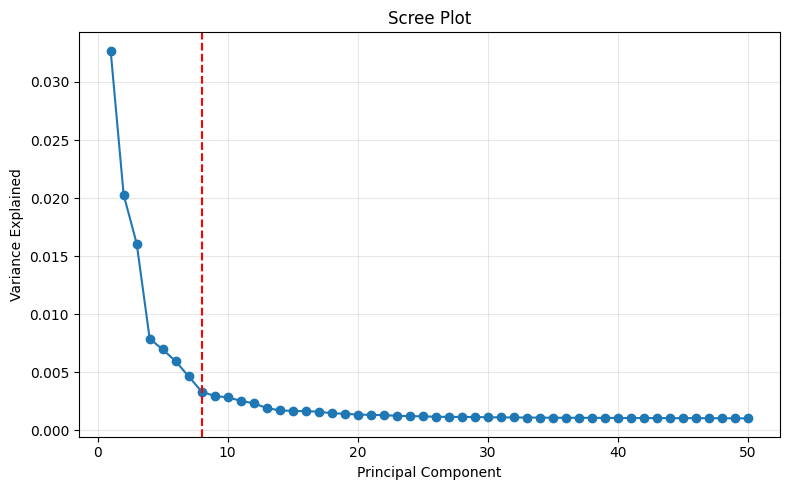

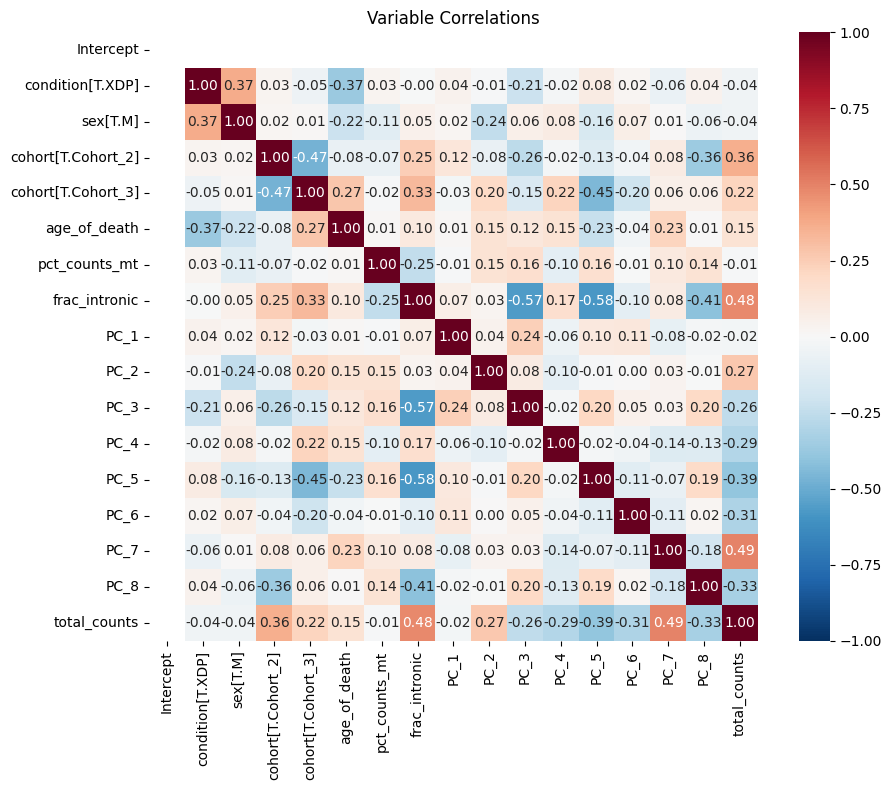

              variable         VIF
0            Intercept  447.374663
4   cohort[T.Cohort_3]    4.068074
16        total_counts    3.903279
7        frac_intronic    3.866297
3   cohort[T.Cohort_2]    3.434487
12                PC_5    3.300076
10                PC_3    2.864606
11                PC_4    1.955423
8                 PC_1    1.695415
14                PC_7    1.643323
13                PC_6    1.574081
1     condition[T.XDP]    1.510197
2             sex[T.M]    1.451463
5         age_of_death    1.443720
15                PC_8    1.440847
9                 PC_2    1.426917
6        pct_counts_mt    1.133281

binary identifiability test. False
Saving qs file...
	Saving files for R coversion...
	Building R obj...

Setting condition reference level to: Control
Levels: Control XDP 
[1] "Creating Seurat object..."


2026-03-27 16:24:56 | [WARNING] R callback write-console: Warning:  
2026-03-27 16:24:56 | [WARNING] R callback write-console:  Data is of class dgTMatrix. Coercing to dgCMatrix.
  


[1] "Saving Seurat object as .qs..."
Running Nebula...
cmd list: ['bash', '/home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh', '--path', '/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/DFC/PCA_nebula/Astrocyte/DFC_combined_QC_mmc_ct-cured.qs', '--id-col', 'donor_id', '--offset-col', 'total_counts', '--n-folds', '40', '--n-cores', '40', '--save-tmp', '0']
Running command: bash /home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh --path /home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/DFC/PCA_nebula/Astrocyte/DFC_combined_QC_mmc_ct-cured.qs --id-col donor_id --offset-col total_counts --n-folds 40 --n-cores 40 --save-tmp 0
Running command: bash /home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh --path /home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/DFC/PCA_nebula/Astrocyte/DFC_combined_QC_mmc_ct-cured.qs --id-col donor_id --offset-col total_counts --n-folds 40 --n-cores 40 --save-tmp 0 --covs condition,age_of_death,sex,pc

/tmp/ipykernel_3017734/2798495869.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(CONTRAST_VARIABLE)[SAMPLE_VARIABLE]


True
/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/DFC/PCA_nebula/Chandelier/DFC_combined_QC_mmc_ct-cured.qs
True
ATTENTION: .X must be raw!
Dropping 1 donor(s) with < 10 cells:
  SCF_22-043                      n_cells=   9  condition=XDP
Retained donors : 43
Filtered genes  : 38601 -> 5356 (min_cells=430, min_counts=50)
Running PCA on Healthy...
Normalising
HVG


/tmp/ipykernel_3017734/2798495869.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(CONTRAST_VARIABLE)[SAMPLE_VARIABLE]


Scaling
PCA on Healthy
Auto-selected 5 PCs via elbow (10.9% variance explained using 50)
Done.
Running PCA on Diseased...
Normalising


... storing 'ct_for_deg' as categorical


Scaling
PCA on Diseased
Done.
Saving h5ad file...
adata intact: 973 cells, 5356 genes
ATTENTION: Dropping 0 cells with NaN covariates: []
~ condition + age_of_death + sex + pct_counts_mt + frac_intronic + cohort + PC_1 + PC_2 + PC_3 + PC_4 + PC_5 + total_counts


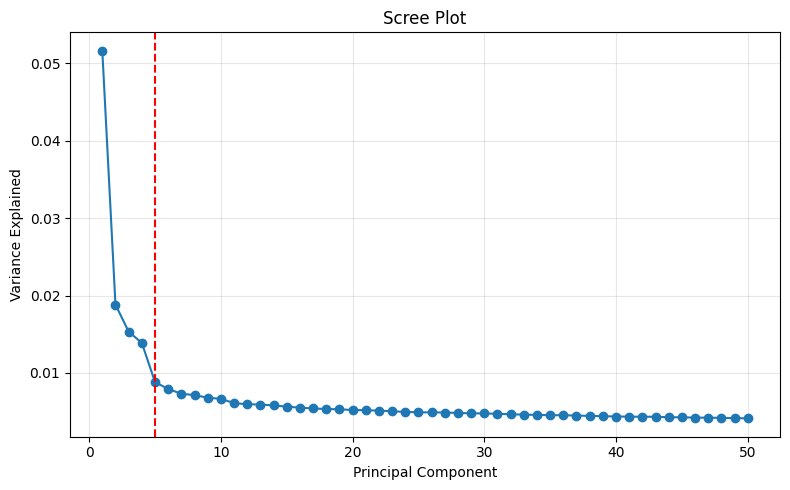

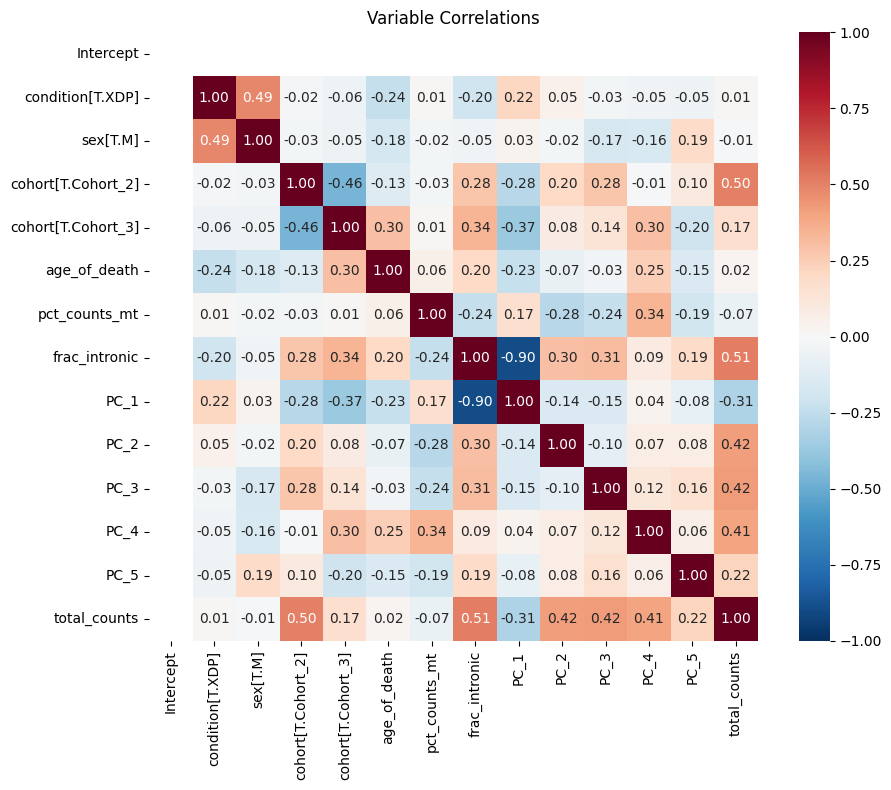

              variable         VIF
0            Intercept  952.056481
8                 PC_1   15.086092
7        frac_intronic   13.583737
3   cohort[T.Cohort_2]    5.575090
4   cohort[T.Cohort_3]    5.148436
13        total_counts    3.761653
10                PC_3    2.651003
9                 PC_2    2.171865
11                PC_4    1.965522
2             sex[T.M]    1.644400
6        pct_counts_mt    1.596797
12                PC_5    1.553680
1     condition[T.XDP]    1.533682
5         age_of_death    1.312194

binary identifiability test. False
Saving qs file...
	Saving files for R coversion...
	Building R obj...

Setting condition reference level to: Control
Levels: Control XDP 
[1] "Creating Seurat object..."


2026-03-27 16:28:11 | [WARNING] R callback write-console: Warning:  
2026-03-27 16:28:11 | [WARNING] R callback write-console:  Data is of class dgTMatrix. Coercing to dgCMatrix.
  


[1] "Saving Seurat object as .qs..."
Running Nebula...
cmd list: ['bash', '/home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh', '--path', '/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/DFC/PCA_nebula/Chandelier/DFC_combined_QC_mmc_ct-cured.qs', '--id-col', 'donor_id', '--offset-col', 'total_counts', '--n-folds', '40', '--n-cores', '40', '--save-tmp', '0']
Running command: bash /home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh --path /home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/DFC/PCA_nebula/Chandelier/DFC_combined_QC_mmc_ct-cured.qs --id-col donor_id --offset-col total_counts --n-folds 40 --n-cores 40 --save-tmp 0
Running command: bash /home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh --path /home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/DFC/PCA_nebula/Chandelier/DFC_combined_QC_mmc_ct-cured.qs --id-col donor_id --offset-col total_counts --n-folds 40 --n-cores 40 --save-tmp 0 --covs condition,age_of_death,sex

/tmp/ipykernel_3017734/2798495869.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(CONTRAST_VARIABLE)[SAMPLE_VARIABLE]
/tmp/ipykernel_3017734/2798495869.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(CONTRAST_VARIABLE)[SAMPLE_VARIABLE]


True
/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/DFC/PCA_nebula/Fibroblasts/DFC_combined_QC_mmc_ct-cured.qs
True
ATTENTION: .X must be raw!
Dropping 29 donor(s) with < 10 cells:
  SCF-18-003                      n_cells=   1  condition=XDP
  SCF-18-004                      n_cells=   1  condition=XDP
  SCF-19-014                      n_cells=   3  condition=XDP
  SCF-20-023                      n_cells=   4  condition=XDP
  SCF-20-025                      n_cells=   2  condition=XDP
  SCF-21-030                      n_cells=   2  condition=XDP
  SCF-22-042                      n_cells=   2  condition=XDP
  SCF-22-054CM                    n_cells=   3  condition=Control
  SCF-22-058CF                    n_cells=   2  condition=Control
  SCF_20-024                      n_cells=   2  condition=XDP
  SCF_21_029                      n_cells=   1  condition=XDP
  SCF_21_034                      n_cells=   1  condition=XDP
  SCF_21_038                      n_cells=   1  condition=XDP
  S

/tmp/ipykernel_3017734/2798495869.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(CONTRAST_VARIABLE)[SAMPLE_VARIABLE]


Normalising
HVG
Scaling
PCA on Healthy
Auto-selected 9 PCs via elbow (17.0% variance explained using 50)
Done.
Running PCA on Diseased...
Normalising
Scaling
PCA on Diseased
Done.
Saving h5ad file...
adata intact: 25965 cells, 20717 genes
ATTENTION: Dropping 0 cells with NaN covariates: []


... storing 'ct_for_deg' as categorical


~ condition + age_of_death + sex + pct_counts_mt + frac_intronic + cohort + PC_1 + PC_2 + PC_3 + PC_4 + PC_5 + PC_6 + PC_7 + PC_8 + PC_9 + total_counts


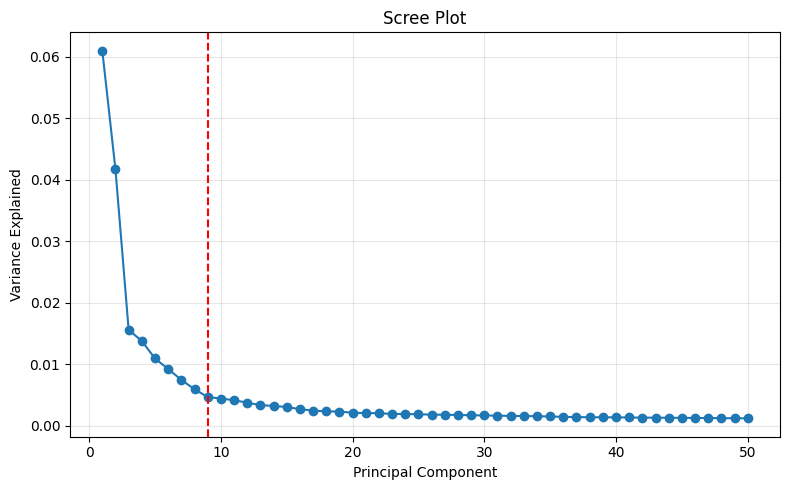

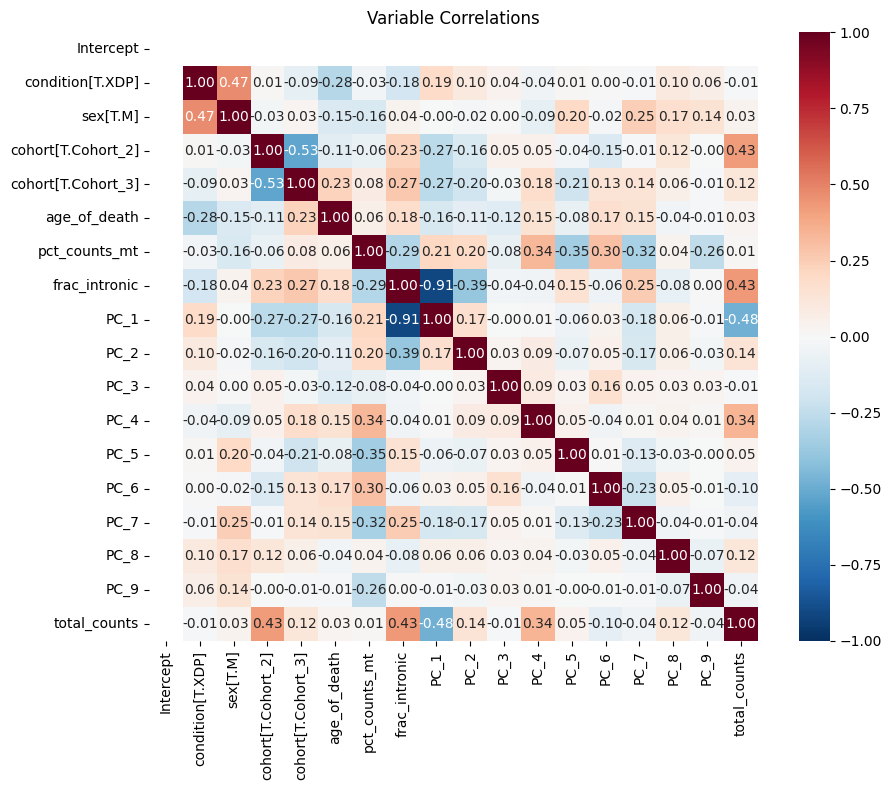

              variable         VIF
0            Intercept  746.721492
7        frac_intronic   11.205638
8                 PC_1    9.817611
3   cohort[T.Cohort_2]    4.615525
4   cohort[T.Cohort_3]    4.248569
17        total_counts    2.899014
9                 PC_2    2.816326
6        pct_counts_mt    2.318630
12                PC_5    2.084254
11                PC_4    1.884364
2             sex[T.M]    1.732110
14                PC_7    1.729878
1     condition[T.XDP]    1.483459
13                PC_6    1.410224
5         age_of_death    1.294893
16                PC_9    1.233217
15                PC_8    1.169444
10                PC_3    1.147952

binary identifiability test. False
Saving qs file...
	Saving files for R coversion...
	Building R obj...

Setting condition reference level to: Control
Levels: Control XDP 
[1] "Creating Seurat object..."


2026-03-27 16:32:01 | [WARNING] R callback write-console: Warning:  
2026-03-27 16:32:01 | [WARNING] R callback write-console:  Data is of class dgTMatrix. Coercing to dgCMatrix.
  


[1] "Saving Seurat object as .qs..."
Running Nebula...
cmd list: ['bash', '/home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh', '--path', '/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/DFC/PCA_nebula/L2/3_IT/DFC_combined_QC_mmc_ct-cured.qs', '--id-col', 'donor_id', '--offset-col', 'total_counts', '--n-folds', '40', '--n-cores', '40', '--save-tmp', '0']
Running command: bash /home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh --path /home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/DFC/PCA_nebula/L2/3_IT/DFC_combined_QC_mmc_ct-cured.qs --id-col donor_id --offset-col total_counts --n-folds 40 --n-cores 40 --save-tmp 0
Running command: bash /home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh --path /home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/DFC/PCA_nebula/L2/3_IT/DFC_combined_QC_mmc_ct-cured.qs --id-col donor_id --offset-col total_counts --n-folds 40 --n-cores 40 --save-tmp 0 --covs condition,age_of_death,sex,pct_coun

/tmp/ipykernel_3017734/2798495869.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(CONTRAST_VARIABLE)[SAMPLE_VARIABLE]


PCA on Healthy
Auto-selected 7 PCs via elbow (20.4% variance explained using 50)
Done.
Running PCA on Diseased...
Normalising


... storing 'ct_for_deg' as categorical


Scaling
PCA on Diseased
Done.
Saving h5ad file...
adata intact: 485 cells, 5967 genes
ATTENTION: Dropping 0 cells with NaN covariates: []
~ condition + age_of_death + sex + pct_counts_mt + frac_intronic + cohort + PC_1 + PC_2 + PC_3 + PC_4 + PC_5 + PC_6 + PC_7 + total_counts


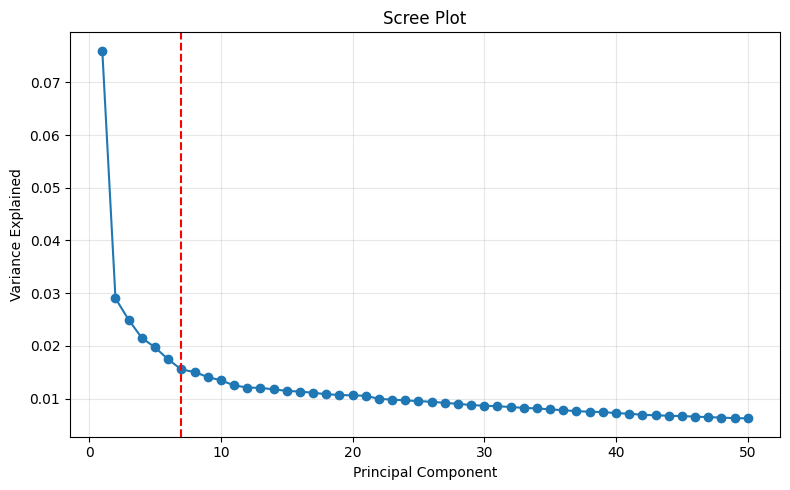

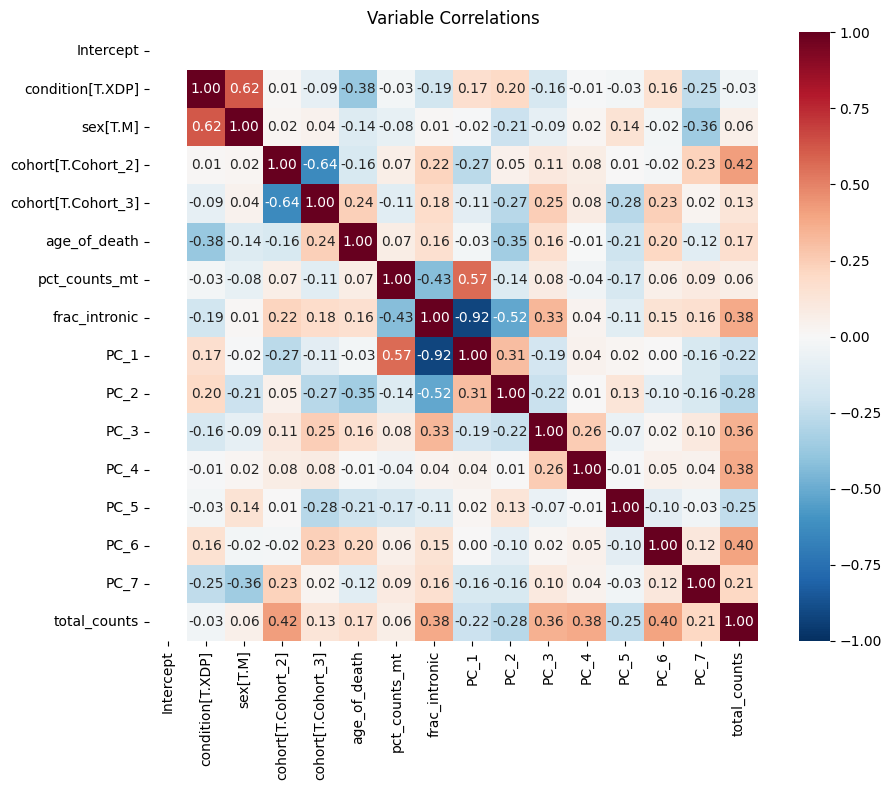

              variable          VIF
0            Intercept  1264.084355
7        frac_intronic    18.715418
8                 PC_1    16.306476
3   cohort[T.Cohort_2]     5.192795
4   cohort[T.Cohort_3]     4.438849
9                 PC_2     3.415335
2             sex[T.M]     3.279129
1     condition[T.XDP]     2.965076
15        total_counts     2.950353
6        pct_counts_mt     2.355734
13                PC_6     1.855425
10                PC_3     1.771358
5         age_of_death     1.698645
14                PC_7     1.669730
12                PC_5     1.633986
11                PC_4     1.330796

binary identifiability test. False
Saving qs file...
	Saving files for R coversion...
	Building R obj...

Setting condition reference level to: Control
Levels: Control XDP 
[1] "Creating Seurat object..."


2026-03-27 16:42:00 | [WARNING] R callback write-console: Warning:  
2026-03-27 16:42:00 | [WARNING] R callback write-console:  Data is of class dgTMatrix. Coercing to dgCMatrix.
  


[1] "Saving Seurat object as .qs..."
Running Nebula...
cmd list: ['bash', '/home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh', '--path', '/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/DFC/PCA_nebula/L4_IT_1/DFC_combined_QC_mmc_ct-cured.qs', '--id-col', 'donor_id', '--offset-col', 'total_counts', '--n-folds', '40', '--n-cores', '40', '--save-tmp', '0']
Running command: bash /home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh --path /home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/DFC/PCA_nebula/L4_IT_1/DFC_combined_QC_mmc_ct-cured.qs --id-col donor_id --offset-col total_counts --n-folds 40 --n-cores 40 --save-tmp 0
Running command: bash /home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh --path /home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/DFC/PCA_nebula/L4_IT_1/DFC_combined_QC_mmc_ct-cured.qs --id-col donor_id --offset-col total_counts --n-folds 40 --n-cores 40 --save-tmp 0 --covs condition,age_of_death,sex,pct_coun

/tmp/ipykernel_3017734/2798495869.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(CONTRAST_VARIABLE)[SAMPLE_VARIABLE]


Normalising
HVG
Scaling
PCA on Healthy
Auto-selected 5 PCs via elbow (11.1% variance explained using 50)
Done.
Running PCA on Diseased...
Normalising
Scaling
PCA on Diseased
Done.
Saving h5ad file...
adata intact: 4181 cells, 13550 genes
ATTENTION: Dropping 0 cells with NaN covariates: []


... storing 'ct_for_deg' as categorical


~ condition + age_of_death + sex + pct_counts_mt + frac_intronic + cohort + PC_1 + PC_2 + PC_3 + PC_4 + PC_5 + total_counts


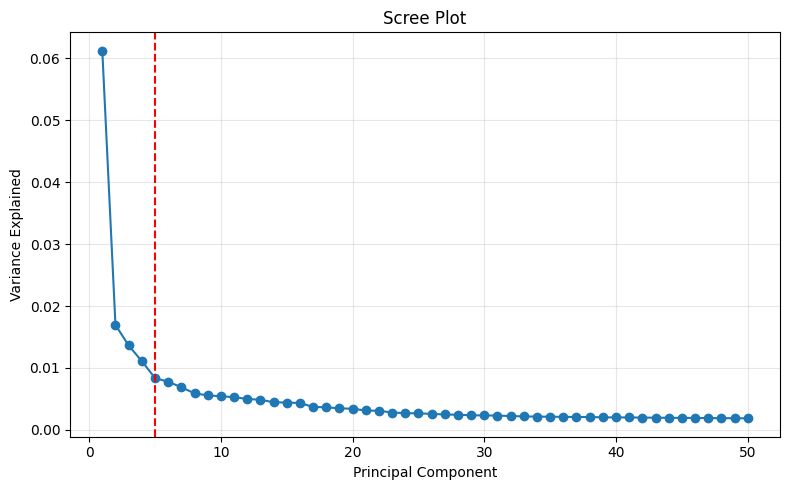

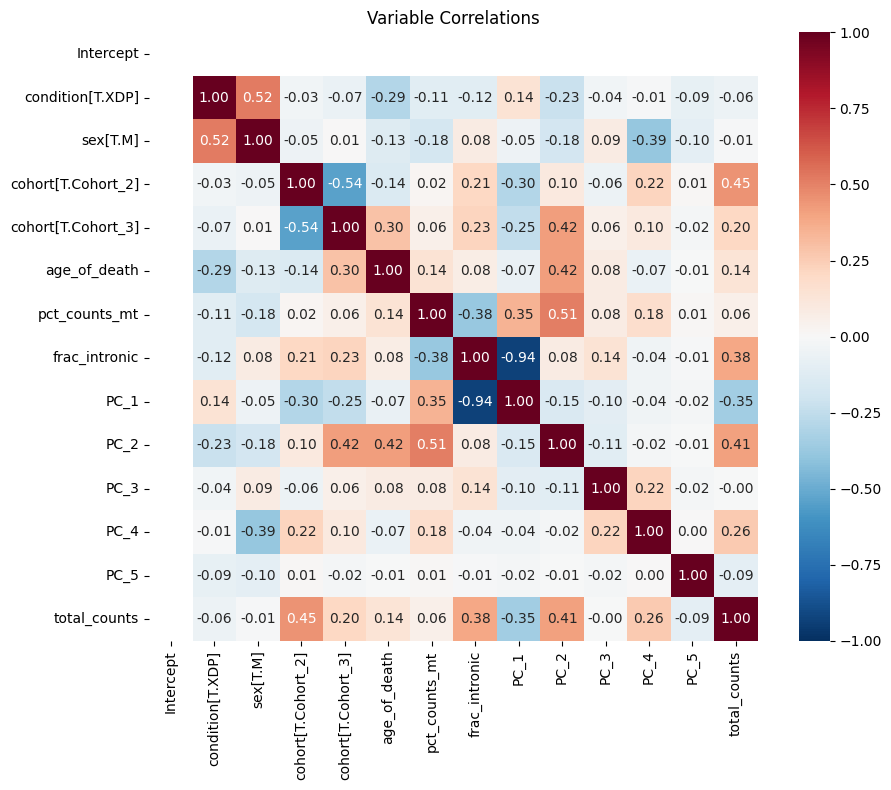

              variable         VIF
0            Intercept  814.587233
8                 PC_1   14.851596
7        frac_intronic   13.162423
3   cohort[T.Cohort_2]    5.338753
4   cohort[T.Cohort_3]    4.836032
9                 PC_2    3.615493
13        total_counts    2.877818
11                PC_4    2.353755
6        pct_counts_mt    2.224696
2             sex[T.M]    2.132200
1     condition[T.XDP]    1.676313
5         age_of_death    1.392052
10                PC_3    1.299467
12                PC_5    1.030907

binary identifiability test. False
Saving qs file...
	Saving files for R coversion...
	Building R obj...

Setting condition reference level to: Control
Levels: Control XDP 
[1] "Creating Seurat object..."


2026-03-27 16:43:20 | [WARNING] R callback write-console: Warning:  
2026-03-27 16:43:20 | [WARNING] R callback write-console:  Data is of class dgTMatrix. Coercing to dgCMatrix.
  


[1] "Saving Seurat object as .qs..."
Running Nebula...
cmd list: ['bash', '/home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh', '--path', '/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/DFC/PCA_nebula/L4_IT_2/DFC_combined_QC_mmc_ct-cured.qs', '--id-col', 'donor_id', '--offset-col', 'total_counts', '--n-folds', '40', '--n-cores', '40', '--save-tmp', '0']
Running command: bash /home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh --path /home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/DFC/PCA_nebula/L4_IT_2/DFC_combined_QC_mmc_ct-cured.qs --id-col donor_id --offset-col total_counts --n-folds 40 --n-cores 40 --save-tmp 0
Running command: bash /home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh --path /home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/DFC/PCA_nebula/L4_IT_2/DFC_combined_QC_mmc_ct-cured.qs --id-col donor_id --offset-col total_counts --n-folds 40 --n-cores 40 --save-tmp 0 --covs condition,age_of_death,sex,pct_coun

/tmp/ipykernel_3017734/2798495869.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(CONTRAST_VARIABLE)[SAMPLE_VARIABLE]


Scaling
PCA on Healthy
Auto-selected 6 PCs via elbow (17.2% variance explained using 50)
Done.
Running PCA on Diseased...
Normalising


... storing 'ct_for_deg' as categorical


Scaling
PCA on Diseased
Done.
Saving h5ad file...
adata intact: 733 cells, 7445 genes
ATTENTION: Dropping 0 cells with NaN covariates: []
~ condition + age_of_death + sex + pct_counts_mt + frac_intronic + cohort + PC_1 + PC_2 + PC_3 + PC_4 + PC_5 + PC_6 + total_counts


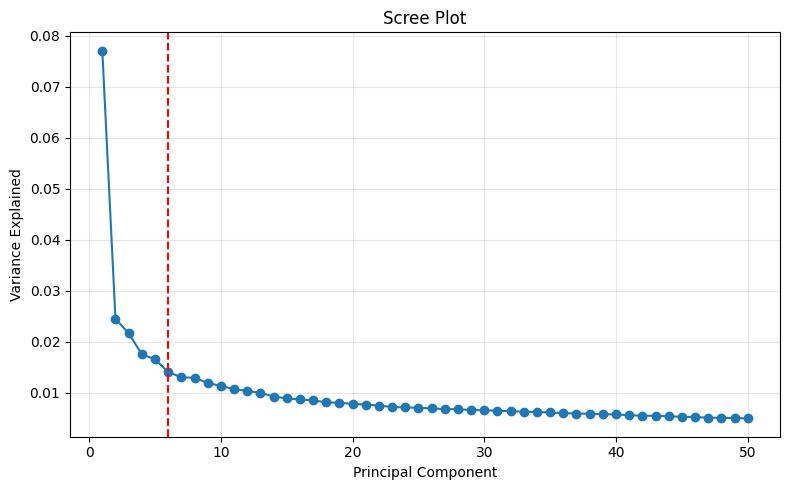

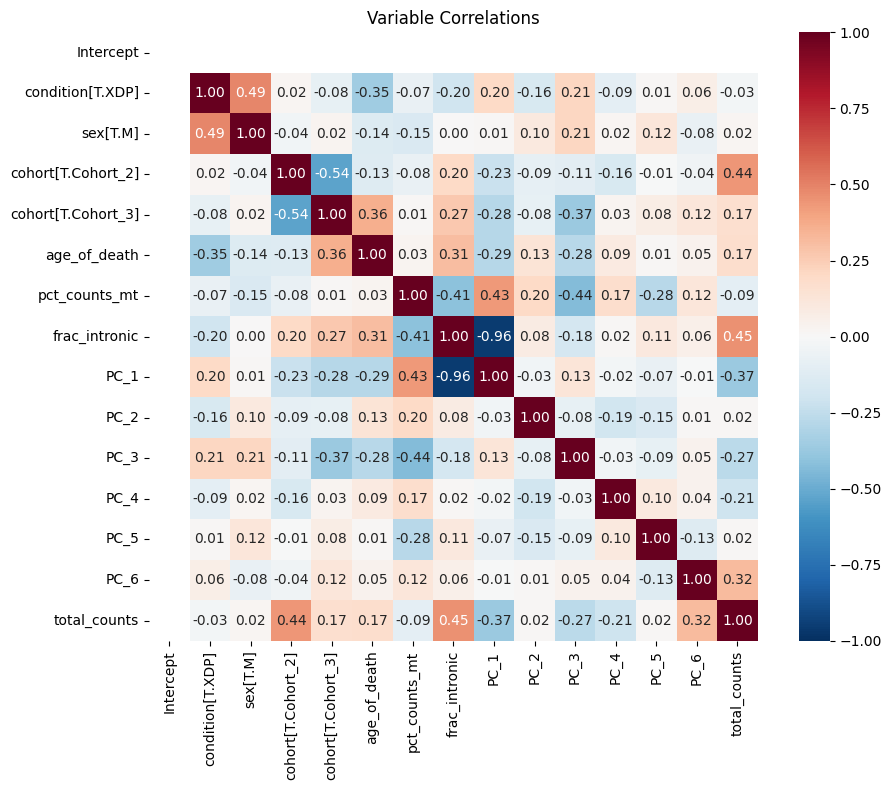

              variable          VIF
0            Intercept  1375.417793
8                 PC_1    20.724232
7        frac_intronic    20.008610
3   cohort[T.Cohort_2]     4.753009
4   cohort[T.Cohort_3]     4.686900
14        total_counts     2.894806
10                PC_3     2.685951
6        pct_counts_mt     2.518825
1     condition[T.XDP]     1.646084
2             sex[T.M]     1.609578
9                 PC_2     1.539454
5         age_of_death     1.405451
11                PC_4     1.399283
13                PC_6     1.359116
12                PC_5     1.277761

binary identifiability test. False
Saving qs file...
	Saving files for R coversion...
	Building R obj...

Setting condition reference level to: Control
Levels: Control XDP 
[1] "Creating Seurat object..."


2026-03-27 16:45:01 | [WARNING] R callback write-console: Warning:  
2026-03-27 16:45:01 | [WARNING] R callback write-console:  Data is of class dgTMatrix. Coercing to dgCMatrix.
  


[1] "Saving Seurat object as .qs..."
Running Nebula...
cmd list: ['bash', '/home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh', '--path', '/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/DFC/PCA_nebula/L4_IT_3/DFC_combined_QC_mmc_ct-cured.qs', '--id-col', 'donor_id', '--offset-col', 'total_counts', '--n-folds', '40', '--n-cores', '40', '--save-tmp', '0']
Running command: bash /home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh --path /home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/DFC/PCA_nebula/L4_IT_3/DFC_combined_QC_mmc_ct-cured.qs --id-col donor_id --offset-col total_counts --n-folds 40 --n-cores 40 --save-tmp 0
Running command: bash /home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh --path /home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/DFC/PCA_nebula/L4_IT_3/DFC_combined_QC_mmc_ct-cured.qs --id-col donor_id --offset-col total_counts --n-folds 40 --n-cores 40 --save-tmp 0 --covs condition,age_of_death,sex,pct_coun

/tmp/ipykernel_3017734/2798495869.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(CONTRAST_VARIABLE)[SAMPLE_VARIABLE]


HVG
Scaling
PCA on Healthy
Auto-selected 7 PCs via elbow (15.4% variance explained using 50)
Done.
Running PCA on Diseased...
Normalising
Scaling
PCA on Diseased
Done.
Saving h5ad file...
adata intact: 1797 cells, 10721 genes
ATTENTION: Dropping 0 cells with NaN covariates: []


... storing 'ct_for_deg' as categorical


~ condition + age_of_death + sex + pct_counts_mt + frac_intronic + cohort + PC_1 + PC_2 + PC_3 + PC_4 + PC_5 + PC_6 + PC_7 + total_counts


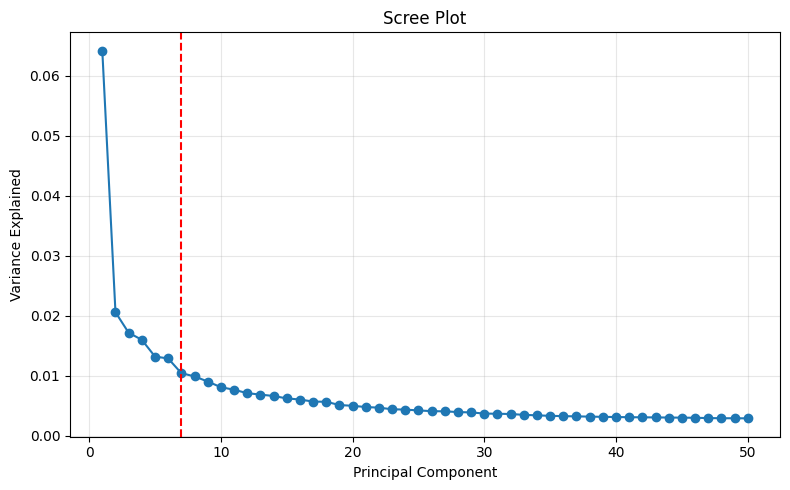

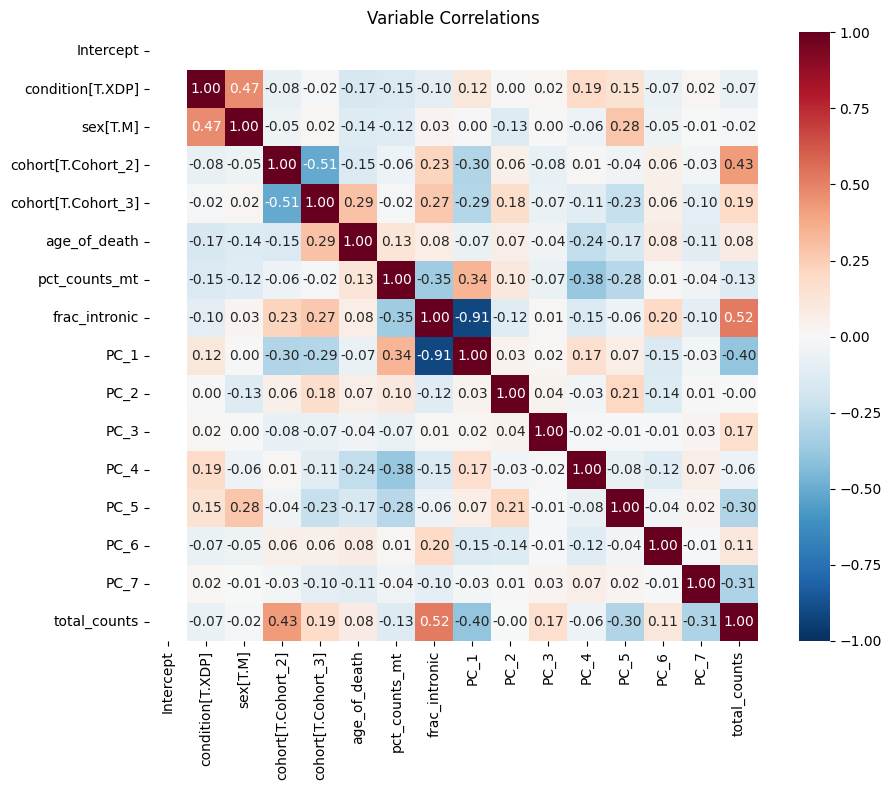

              variable         VIF
0            Intercept  797.010281
8                 PC_1   11.041941
7        frac_intronic   10.332925
3   cohort[T.Cohort_2]    4.721422
4   cohort[T.Cohort_3]    4.096212
15        total_counts    3.520880
6        pct_counts_mt    1.917160
12                PC_5    1.914341
11                PC_4    1.614027
9                 PC_2    1.555678
2             sex[T.M]    1.538497
1     condition[T.XDP]    1.412582
10                PC_3    1.283868
14                PC_7    1.224413
5         age_of_death    1.217716
13                PC_6    1.104913

binary identifiability test. False
Saving qs file...
	Saving files for R coversion...
	Building R obj...

Setting condition reference level to: Control
Levels: Control XDP 
[1] "Creating Seurat object..."


2026-03-27 16:46:11 | [WARNING] R callback write-console: Warning:  
2026-03-27 16:46:11 | [WARNING] R callback write-console:  Data is of class dgTMatrix. Coercing to dgCMatrix.
  


[1] "Saving Seurat object as .qs..."
Running Nebula...
cmd list: ['bash', '/home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh', '--path', '/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/DFC/PCA_nebula/L4_IT_4/DFC_combined_QC_mmc_ct-cured.qs', '--id-col', 'donor_id', '--offset-col', 'total_counts', '--n-folds', '40', '--n-cores', '40', '--save-tmp', '0']
Running command: bash /home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh --path /home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/DFC/PCA_nebula/L4_IT_4/DFC_combined_QC_mmc_ct-cured.qs --id-col donor_id --offset-col total_counts --n-folds 40 --n-cores 40 --save-tmp 0
Running command: bash /home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh --path /home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/DFC/PCA_nebula/L4_IT_4/DFC_combined_QC_mmc_ct-cured.qs --id-col donor_id --offset-col total_counts --n-folds 40 --n-cores 40 --save-tmp 0 --covs condition,age_of_death,sex,pct_coun

/tmp/ipykernel_3017734/2798495869.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(CONTRAST_VARIABLE)[SAMPLE_VARIABLE]


Scaling
PCA on Healthy
Auto-selected 7 PCs via elbow (17.6% variance explained using 50)
Done.
Running PCA on Diseased...
Normalising
Scaling
PCA on Diseased
Done.
Saving h5ad file...
adata intact: 1080 cells, 8630 genes
ATTENTION: Dropping 0 cells with NaN covariates: []


... storing 'ct_for_deg' as categorical


~ condition + age_of_death + sex + pct_counts_mt + frac_intronic + cohort + PC_1 + PC_2 + PC_3 + PC_4 + PC_5 + PC_6 + PC_7 + total_counts


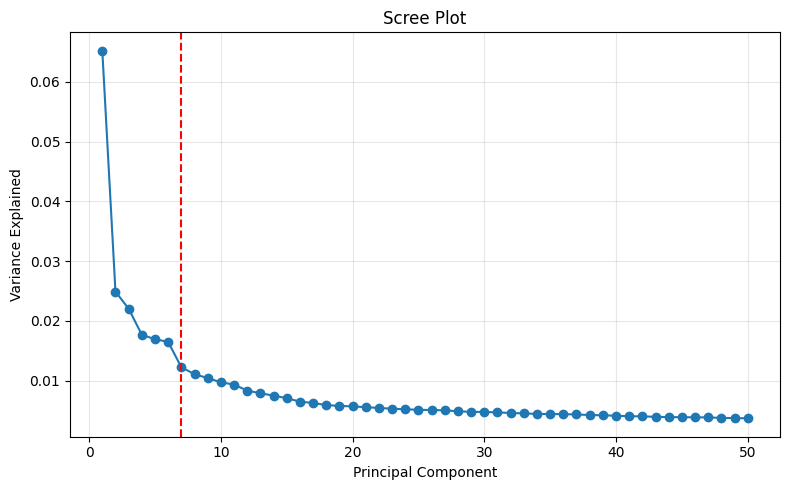

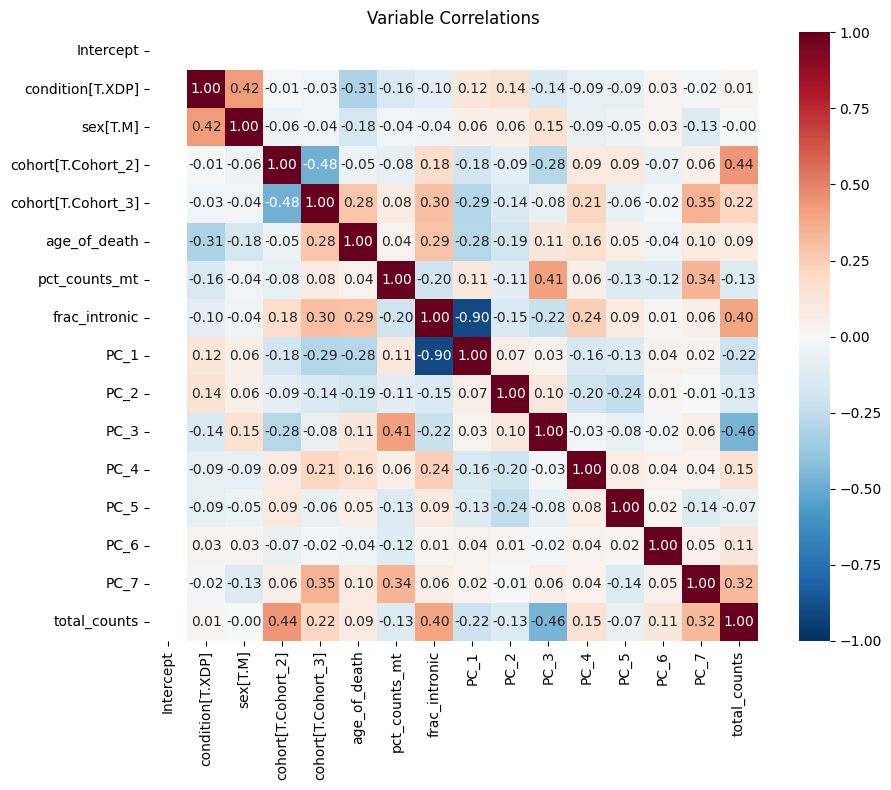

              variable          VIF
0            Intercept  1088.655914
8                 PC_1    12.818162
7        frac_intronic    12.410666
4   cohort[T.Cohort_3]     4.385938
3   cohort[T.Cohort_2]     4.350562
15        total_counts     2.804532
10                PC_3     2.403702
14                PC_7     2.106378
6        pct_counts_mt     1.606761
2             sex[T.M]     1.451140
1     condition[T.XDP]     1.439922
11                PC_4     1.354435
9                 PC_2     1.344206
5         age_of_death     1.340997
12                PC_5     1.186741
13                PC_6     1.115099

binary identifiability test. False
Saving qs file...
	Saving files for R coversion...
	Building R obj...

Setting condition reference level to: Control
Levels: Control XDP 
[1] "Creating Seurat object..."


2026-03-27 16:47:25 | [WARNING] R callback write-console: Warning:  
2026-03-27 16:47:25 | [WARNING] R callback write-console:  Data is of class dgTMatrix. Coercing to dgCMatrix.
  


[1] "Saving Seurat object as .qs..."
Running Nebula...
cmd list: ['bash', '/home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh', '--path', '/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/DFC/PCA_nebula/L5/6_NP/DFC_combined_QC_mmc_ct-cured.qs', '--id-col', 'donor_id', '--offset-col', 'total_counts', '--n-folds', '40', '--n-cores', '40', '--save-tmp', '0']
Running command: bash /home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh --path /home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/DFC/PCA_nebula/L5/6_NP/DFC_combined_QC_mmc_ct-cured.qs --id-col donor_id --offset-col total_counts --n-folds 40 --n-cores 40 --save-tmp 0
Running command: bash /home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh --path /home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/DFC/PCA_nebula/L5/6_NP/DFC_combined_QC_mmc_ct-cured.qs --id-col donor_id --offset-col total_counts --n-folds 40 --n-cores 40 --save-tmp 0 --covs condition,age_of_death,sex,pct_coun

/tmp/ipykernel_3017734/2798495869.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(CONTRAST_VARIABLE)[SAMPLE_VARIABLE]


Done.
Running PCA on Diseased...
Normalising


... storing 'ct_for_deg' as categorical


Scaling
PCA on Diseased
Done.
Saving h5ad file...
adata intact: 111 cells, 6442 genes
ATTENTION: Dropping 0 cells with NaN covariates: []
~ condition + age_of_death + sex + pct_counts_mt + frac_intronic + cohort + PC_1 + PC_2 + PC_3 + PC_4 + PC_5 + PC_6 + PC_7 + PC_8 + PC_9 + PC_10 + PC_11 + PC_12 + PC_13 + PC_14 + PC_15 + total_counts


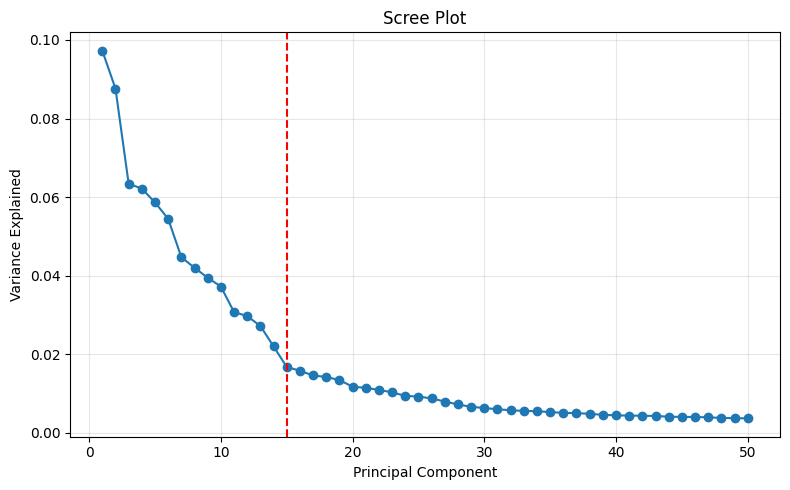

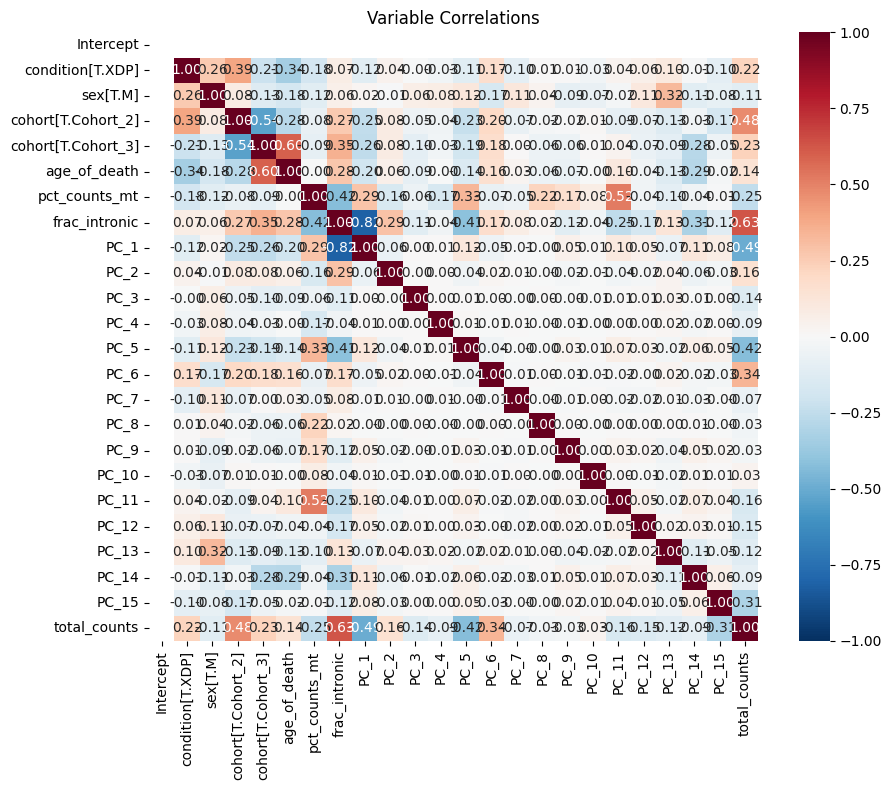

              variable          VIF
0            Intercept  2178.137776
7        frac_intronic    36.125549
8                 PC_1    28.344424
3   cohort[T.Cohort_2]    13.007011
4   cohort[T.Cohort_3]    11.031492
12                PC_5     8.429238
13                PC_6     4.695077
21               PC_14     3.829958
2             sex[T.M]     3.531640
23        total_counts     3.516966
9                 PC_2     3.401876
6        pct_counts_mt     2.622324
20               PC_13     2.400146
1     condition[T.XDP]     2.276025
10                PC_3     2.044146
5         age_of_death     2.018140
18               PC_11     2.015100
19               PC_12     1.818776
22               PC_15     1.328592
11                PC_4     1.273770
15                PC_8     1.225668
16                PC_9     1.132614
14                PC_7     1.105015
17               PC_10     1.024720

binary identifiability test. False
Saving qs file...
	Saving files for R coversion...
	Building R o

2026-03-27 16:48:35 | [WARNING] R callback write-console: Warning:  
2026-03-27 16:48:35 | [WARNING] R callback write-console:  Data is of class dgTMatrix. Coercing to dgCMatrix.
  


[1] "Saving Seurat object as .qs..."
Running Nebula...
cmd list: ['bash', '/home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh', '--path', '/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/DFC/PCA_nebula/L5_ET_C/DFC_combined_QC_mmc_ct-cured.qs', '--id-col', 'donor_id', '--offset-col', 'total_counts', '--n-folds', '40', '--n-cores', '40', '--save-tmp', '0']
Running command: bash /home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh --path /home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/DFC/PCA_nebula/L5_ET_C/DFC_combined_QC_mmc_ct-cured.qs --id-col donor_id --offset-col total_counts --n-folds 40 --n-cores 40 --save-tmp 0
Running command: bash /home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh --path /home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/DFC/PCA_nebula/L5_ET_C/DFC_combined_QC_mmc_ct-cured.qs --id-col donor_id --offset-col total_counts --n-folds 40 --n-cores 40 --save-tmp 0 --covs condition,age_of_death,sex,pct_coun

/tmp/ipykernel_3017734/2798495869.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(CONTRAST_VARIABLE)[SAMPLE_VARIABLE]


HVG
Scaling
PCA on Healthy
Auto-selected 5 PCs via elbow (14.6% variance explained using 50)
Done.
Running PCA on Diseased...
Normalising
Scaling
PCA on Diseased
Done.
Saving h5ad file...
adata intact: 1263 cells, 10012 genes
ATTENTION: Dropping 0 cells with NaN covariates: []


... storing 'ct_for_deg' as categorical


~ condition + age_of_death + sex + pct_counts_mt + frac_intronic + cohort + PC_1 + PC_2 + PC_3 + PC_4 + PC_5 + total_counts


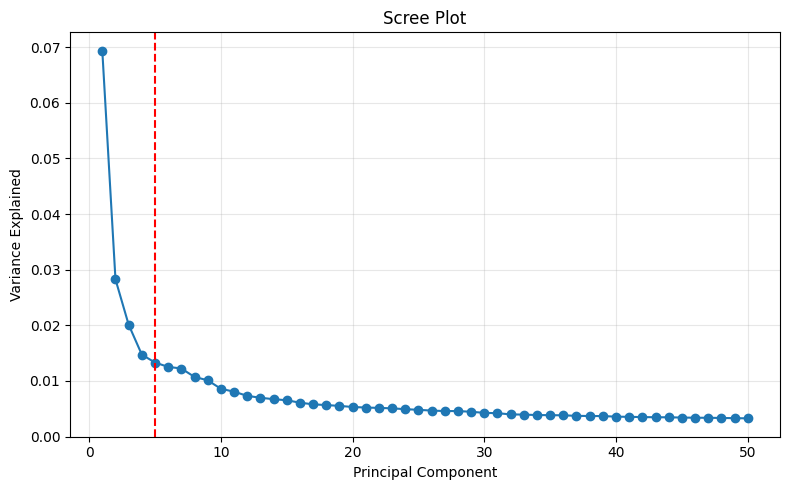

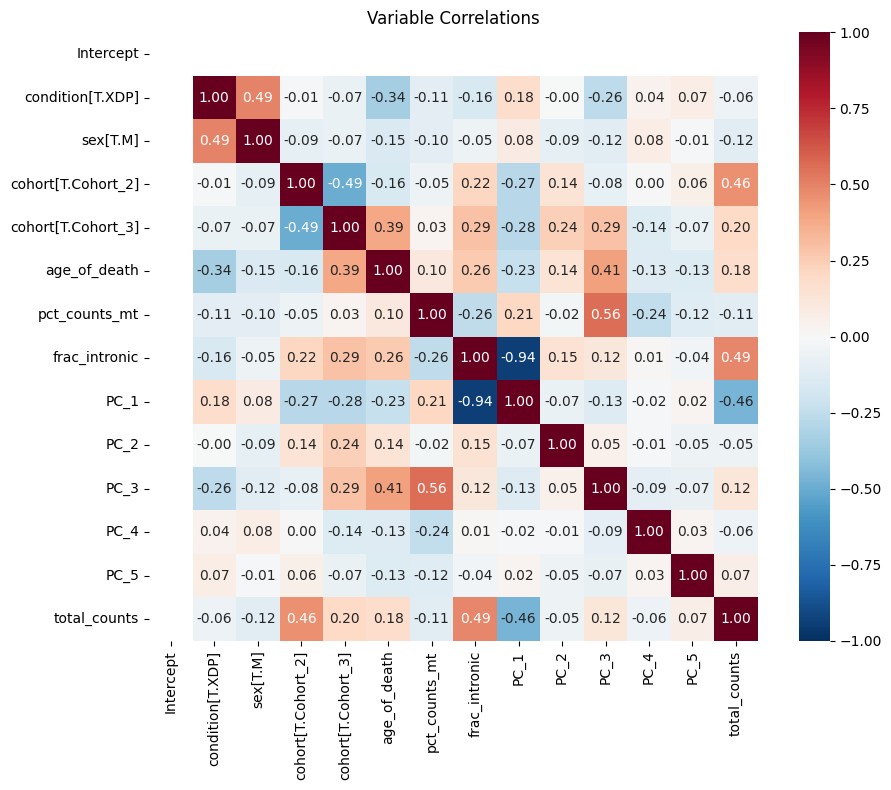

              variable         VIF
0            Intercept  969.974980
8                 PC_1   13.097910
7        frac_intronic   13.020316
3   cohort[T.Cohort_2]    4.356289
4   cohort[T.Cohort_3]    3.648789
13        total_counts    2.872875
10                PC_3    2.008397
6        pct_counts_mt    1.930156
9                 PC_2    1.886917
1     condition[T.XDP]    1.569286
5         age_of_death    1.545593
2             sex[T.M]    1.403411
11                PC_4    1.137457
12                PC_5    1.054201

binary identifiability test. False
Saving qs file...
	Saving files for R coversion...
	Building R obj...

Setting condition reference level to: Control
Levels: Control XDP 
[1] "Creating Seurat object..."


2026-03-27 16:49:35 | [WARNING] R callback write-console: Warning:  
2026-03-27 16:49:35 | [WARNING] R callback write-console:  Data is of class dgTMatrix. Coercing to dgCMatrix.
  


[1] "Saving Seurat object as .qs..."
Running Nebula...
cmd list: ['bash', '/home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh', '--path', '/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/DFC/PCA_nebula/L5_IT_A/DFC_combined_QC_mmc_ct-cured.qs', '--id-col', 'donor_id', '--offset-col', 'total_counts', '--n-folds', '40', '--n-cores', '40', '--save-tmp', '0']
Running command: bash /home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh --path /home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/DFC/PCA_nebula/L5_IT_A/DFC_combined_QC_mmc_ct-cured.qs --id-col donor_id --offset-col total_counts --n-folds 40 --n-cores 40 --save-tmp 0
Running command: bash /home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh --path /home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/DFC/PCA_nebula/L5_IT_A/DFC_combined_QC_mmc_ct-cured.qs --id-col donor_id --offset-col total_counts --n-folds 40 --n-cores 40 --save-tmp 0 --covs condition,age_of_death,sex,pct_coun

/tmp/ipykernel_3017734/2798495869.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(CONTRAST_VARIABLE)[SAMPLE_VARIABLE]


Normalising
HVG
Scaling
PCA on Healthy
Auto-selected 6 PCs via elbow (15.8% variance explained using 50)
Done.
Running PCA on Diseased...
Normalising
Scaling
PCA on Diseased
Done.
Saving h5ad file...
adata intact: 6322 cells, 15853 genes
ATTENTION: Dropping 0 cells with NaN covariates: []


... storing 'ct_for_deg' as categorical


~ condition + age_of_death + sex + pct_counts_mt + frac_intronic + cohort + PC_1 + PC_2 + PC_3 + PC_4 + PC_5 + PC_6 + total_counts


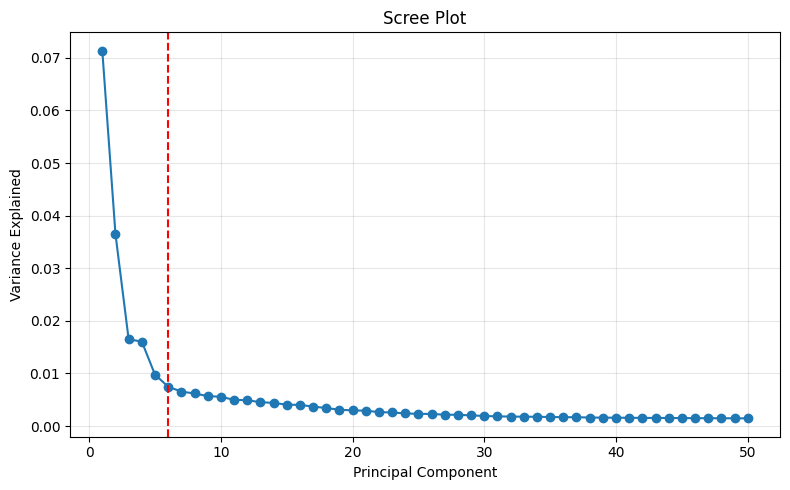

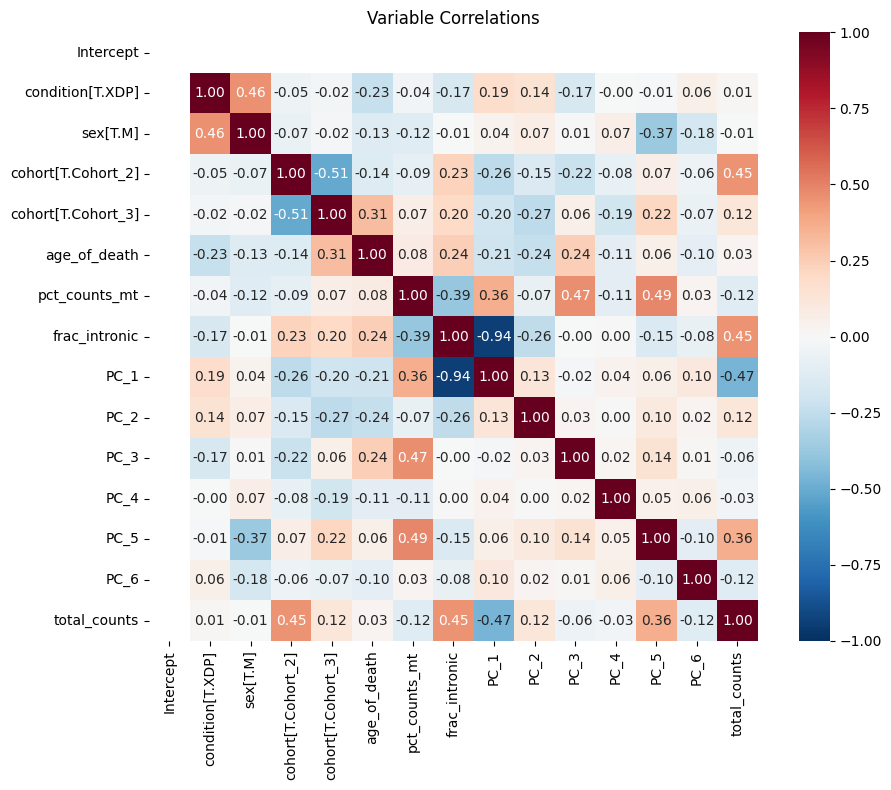

              variable         VIF
0            Intercept  932.351237
7        frac_intronic   15.274653
8                 PC_1   14.032909
3   cohort[T.Cohort_2]    4.746203
4   cohort[T.Cohort_3]    4.058813
14        total_counts    3.224331
12                PC_5    3.066885
9                 PC_2    2.652231
6        pct_counts_mt    2.465994
2             sex[T.M]    1.973375
10                PC_3    1.698633
1     condition[T.XDP]    1.566050
11                PC_4    1.379680
5         age_of_death    1.321763
13                PC_6    1.177584

binary identifiability test. False
Saving qs file...
	Saving files for R coversion...
	Building R obj...

Setting condition reference level to: Control
Levels: Control XDP 
[1] "Creating Seurat object..."


2026-03-27 16:51:19 | [WARNING] R callback write-console: Warning:  
2026-03-27 16:51:19 | [WARNING] R callback write-console:  Data is of class dgTMatrix. Coercing to dgCMatrix.
  


[1] "Saving Seurat object as .qs..."
Running Nebula...
cmd list: ['bash', '/home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh', '--path', '/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/DFC/PCA_nebula/L5_IT_B/DFC_combined_QC_mmc_ct-cured.qs', '--id-col', 'donor_id', '--offset-col', 'total_counts', '--n-folds', '40', '--n-cores', '40', '--save-tmp', '0']
Running command: bash /home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh --path /home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/DFC/PCA_nebula/L5_IT_B/DFC_combined_QC_mmc_ct-cured.qs --id-col donor_id --offset-col total_counts --n-folds 40 --n-cores 40 --save-tmp 0
Running command: bash /home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh --path /home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/DFC/PCA_nebula/L5_IT_B/DFC_combined_QC_mmc_ct-cured.qs --id-col donor_id --offset-col total_counts --n-folds 40 --n-cores 40 --save-tmp 0 --covs condition,age_of_death,sex,pct_coun

/tmp/ipykernel_3017734/2798495869.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(CONTRAST_VARIABLE)[SAMPLE_VARIABLE]


HVG
Scaling
PCA on Healthy
Auto-selected 9 PCs via elbow (17.0% variance explained using 50)
Done.
Running PCA on Diseased...
Normalising
Scaling
PCA on Diseased
Done.
Saving h5ad file...
adata intact: 1458 cells, 9763 genes
ATTENTION: Dropping 0 cells with NaN covariates: []


... storing 'ct_for_deg' as categorical


~ condition + age_of_death + sex + pct_counts_mt + frac_intronic + cohort + PC_1 + PC_2 + PC_3 + PC_4 + PC_5 + PC_6 + PC_7 + PC_8 + PC_9 + total_counts


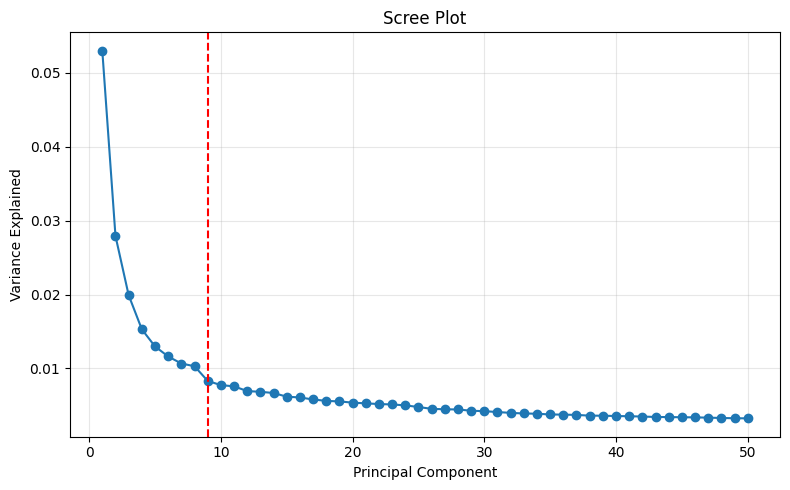

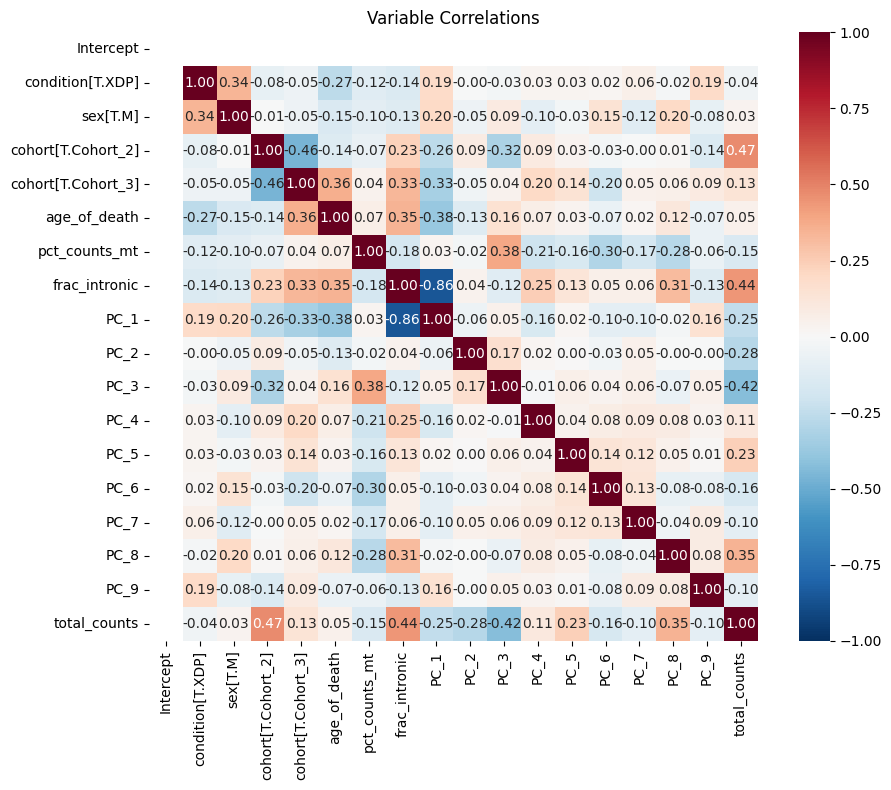

              variable         VIF
0            Intercept  858.486898
8                 PC_1    8.200828
7        frac_intronic    7.849050
3   cohort[T.Cohort_2]    4.068315
4   cohort[T.Cohort_3]    3.465740
17        total_counts    3.287510
15                PC_8    1.852747
10                PC_3    1.842038
6        pct_counts_mt    1.736599
13                PC_6    1.588338
2             sex[T.M]    1.571425
5         age_of_death    1.479310
12                PC_5    1.433465
9                 PC_2    1.409953
1     condition[T.XDP]    1.350879
11                PC_4    1.345299
16                PC_9    1.184152
14                PC_7    1.144635

binary identifiability test. False
Saving qs file...
	Saving files for R coversion...
	Building R obj...

Setting condition reference level to: Control
Levels: Control XDP 
[1] "Creating Seurat object..."


2026-03-27 16:53:41 | [WARNING] R callback write-console: Warning:  
2026-03-27 16:53:41 | [WARNING] R callback write-console:  Data is of class dgTMatrix. Coercing to dgCMatrix.
  


[1] "Saving Seurat object as .qs..."
Running Nebula...
cmd list: ['bash', '/home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh', '--path', '/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/DFC/PCA_nebula/L6_CT/DFC_combined_QC_mmc_ct-cured.qs', '--id-col', 'donor_id', '--offset-col', 'total_counts', '--n-folds', '40', '--n-cores', '40', '--save-tmp', '0']
Running command: bash /home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh --path /home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/DFC/PCA_nebula/L6_CT/DFC_combined_QC_mmc_ct-cured.qs --id-col donor_id --offset-col total_counts --n-folds 40 --n-cores 40 --save-tmp 0
Running command: bash /home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh --path /home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/DFC/PCA_nebula/L6_CT/DFC_combined_QC_mmc_ct-cured.qs --id-col donor_id --offset-col total_counts --n-folds 40 --n-cores 40 --save-tmp 0 --covs condition,age_of_death,sex,pct_counts_mt,

/tmp/ipykernel_3017734/2798495869.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(CONTRAST_VARIABLE)[SAMPLE_VARIABLE]


Normalising
HVG
Scaling
PCA on Healthy
Auto-selected 3 PCs via elbow (10.1% variance explained using 50)
Done.
Running PCA on Diseased...
Normalising
Scaling
PCA on Diseased
Done.
Saving h5ad file...
adata intact: 3322 cells, 13872 genes
ATTENTION: Dropping 0 cells with NaN covariates: []


... storing 'ct_for_deg' as categorical


~ condition + age_of_death + sex + pct_counts_mt + frac_intronic + cohort + PC_1 + PC_2 + PC_3 + total_counts


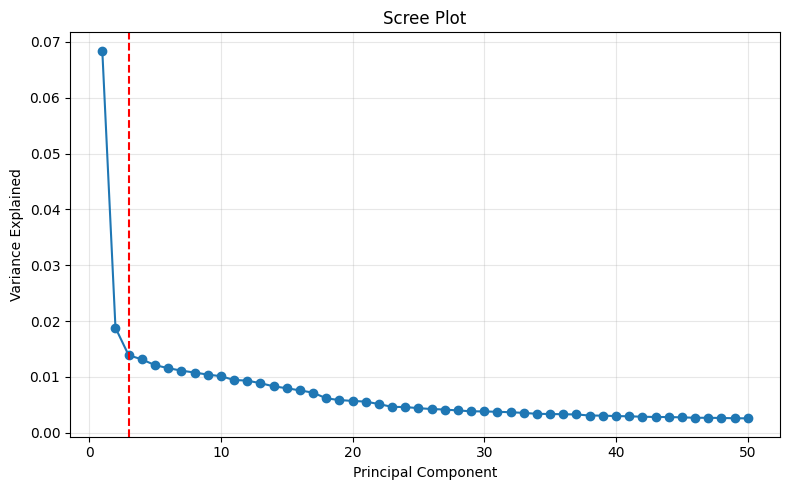

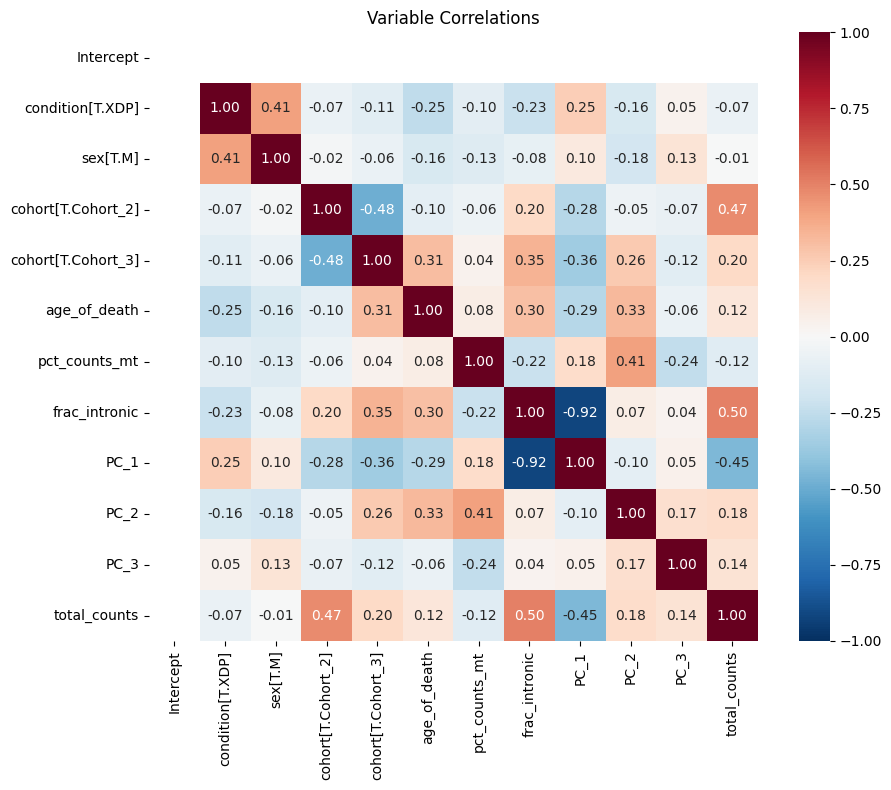

              variable         VIF
0            Intercept  725.236619
8                 PC_1    9.478132
7        frac_intronic    8.867131
3   cohort[T.Cohort_2]    3.824721
4   cohort[T.Cohort_3]    3.186590
11        total_counts    2.641241
9                 PC_2    1.733931
6        pct_counts_mt    1.521595
10                PC_3    1.492986
1     condition[T.XDP]    1.327624
5         age_of_death    1.324315
2             sex[T.M]    1.263203

binary identifiability test. False
Saving qs file...
	Saving files for R coversion...
	Building R obj...

Setting condition reference level to: Control
Levels: Control XDP 
[1] "Creating Seurat object..."


2026-03-27 16:55:09 | [WARNING] R callback write-console: Warning:  
2026-03-27 16:55:09 | [WARNING] R callback write-console:  Data is of class dgTMatrix. Coercing to dgCMatrix.
  


[1] "Saving Seurat object as .qs..."
Running Nebula...
cmd list: ['bash', '/home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh', '--path', '/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/DFC/PCA_nebula/L6_IT/DFC_combined_QC_mmc_ct-cured.qs', '--id-col', 'donor_id', '--offset-col', 'total_counts', '--n-folds', '40', '--n-cores', '40', '--save-tmp', '0']
Running command: bash /home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh --path /home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/DFC/PCA_nebula/L6_IT/DFC_combined_QC_mmc_ct-cured.qs --id-col donor_id --offset-col total_counts --n-folds 40 --n-cores 40 --save-tmp 0
Running command: bash /home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh --path /home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/DFC/PCA_nebula/L6_IT/DFC_combined_QC_mmc_ct-cured.qs --id-col donor_id --offset-col total_counts --n-folds 40 --n-cores 40 --save-tmp 0 --covs condition,age_of_death,sex,pct_counts_mt,

/tmp/ipykernel_3017734/2798495869.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(CONTRAST_VARIABLE)[SAMPLE_VARIABLE]


True
/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/DFC/PCA_nebula/L6b/DFC_combined_QC_mmc_ct-cured.qs
True
ATTENTION: .X must be raw!
Dropping 3 donor(s) with < 10 cells:
  SCF-18-004                      n_cells=   6  condition=XDP
  SCF_22_065CM                    n_cells=   6  condition=Control
  SCF_23_074CF                    n_cells=   9  condition=Control
Retained donors : 40
Filtered genes  : 38601 -> 11269 (min_cells=400, min_counts=50)
Running PCA on Healthy...
Normalising


/tmp/ipykernel_3017734/2798495869.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(CONTRAST_VARIABLE)[SAMPLE_VARIABLE]


HVG
Scaling
PCA on Healthy
Auto-selected 7 PCs via elbow (14.9% variance explained using 50)
Done.
Running PCA on Diseased...
Normalising
Scaling
PCA on Diseased
Done.
Saving h5ad file...
adata intact: 1761 cells, 11269 genes
ATTENTION: Dropping 0 cells with NaN covariates: []


... storing 'ct_for_deg' as categorical


~ condition + age_of_death + sex + pct_counts_mt + frac_intronic + cohort + PC_1 + PC_2 + PC_3 + PC_4 + PC_5 + PC_6 + PC_7 + total_counts


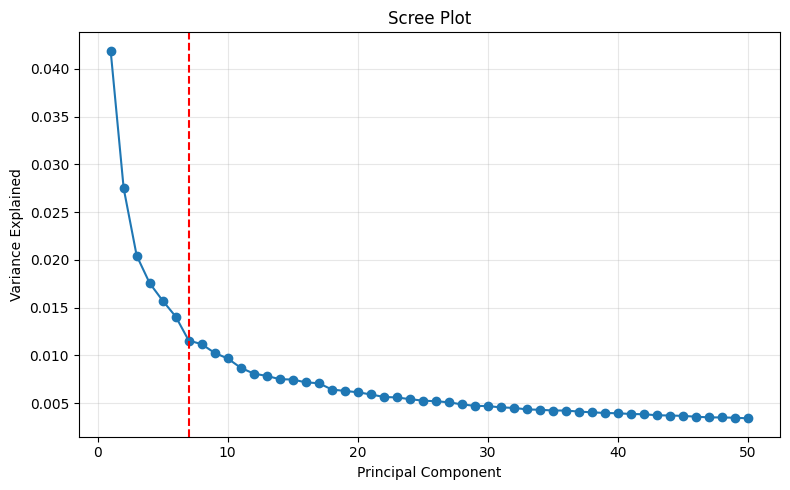

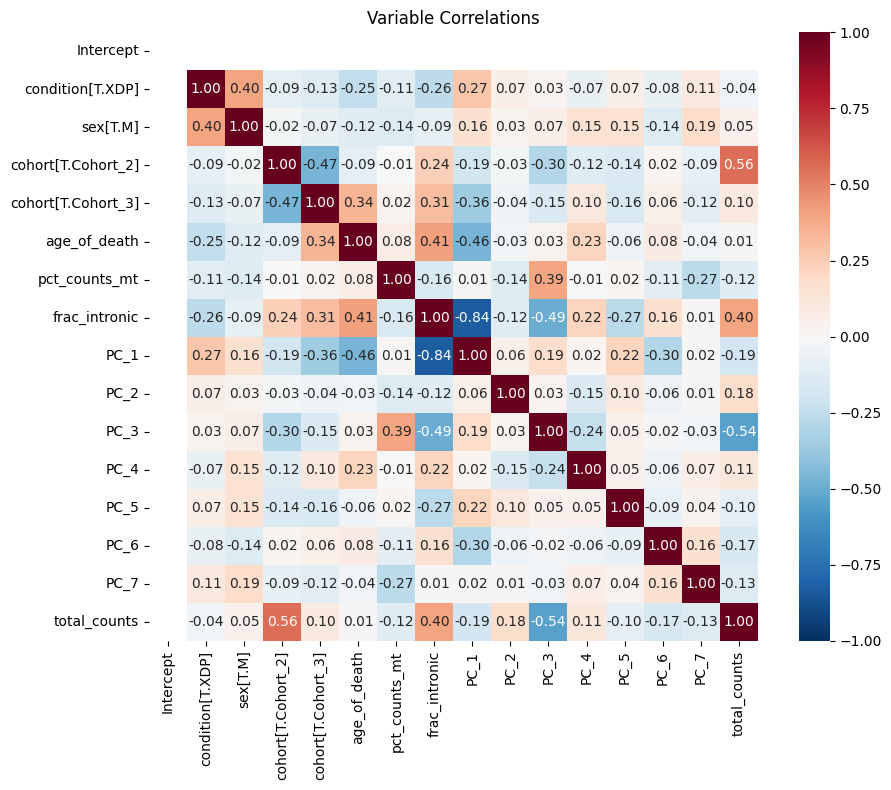

              variable         VIF
0            Intercept  873.414902
7        frac_intronic    8.344868
8                 PC_1    7.296742
3   cohort[T.Cohort_2]    4.163934
15        total_counts    3.264879
4   cohort[T.Cohort_3]    3.150882
10                PC_3    2.737304
5         age_of_death    1.562065
11                PC_4    1.499989
6        pct_counts_mt    1.451912
2             sex[T.M]    1.438150
1     condition[T.XDP]    1.370905
9                 PC_2    1.276922
12                PC_5    1.271111
13                PC_6    1.268570
14                PC_7    1.200400

binary identifiability test. False
Saving qs file...
	Saving files for R coversion...
	Building R obj...

Setting condition reference level to: Control
Levels: Control XDP 
[1] "Creating Seurat object..."


2026-03-27 16:56:49 | [WARNING] R callback write-console: Warning:  
2026-03-27 16:56:49 | [WARNING] R callback write-console:  Data is of class dgTMatrix. Coercing to dgCMatrix.
  


[1] "Saving Seurat object as .qs..."
Running Nebula...
cmd list: ['bash', '/home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh', '--path', '/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/DFC/PCA_nebula/L6b/DFC_combined_QC_mmc_ct-cured.qs', '--id-col', 'donor_id', '--offset-col', 'total_counts', '--n-folds', '40', '--n-cores', '40', '--save-tmp', '0']
Running command: bash /home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh --path /home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/DFC/PCA_nebula/L6b/DFC_combined_QC_mmc_ct-cured.qs --id-col donor_id --offset-col total_counts --n-folds 40 --n-cores 40 --save-tmp 0
Running command: bash /home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh --path /home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/DFC/PCA_nebula/L6b/DFC_combined_QC_mmc_ct-cured.qs --id-col donor_id --offset-col total_counts --n-folds 40 --n-cores 40 --save-tmp 0 --covs condition,age_of_death,sex,pct_counts_mt,frac_i

/tmp/ipykernel_3017734/2798495869.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(CONTRAST_VARIABLE)[SAMPLE_VARIABLE]


HVG
Scaling
PCA on Healthy
Auto-selected 5 PCs via elbow (14.4% variance explained using 50)
Done.
Running PCA on Diseased...
Normalising
Scaling
PCA on Diseased
Done.
Saving h5ad file...
adata intact: 2720 cells, 10577 genes
ATTENTION: Dropping 0 cells with NaN covariates: []


... storing 'ct_for_deg' as categorical


~ condition + age_of_death + sex + pct_counts_mt + frac_intronic + cohort + PC_1 + PC_2 + PC_3 + PC_4 + PC_5 + total_counts


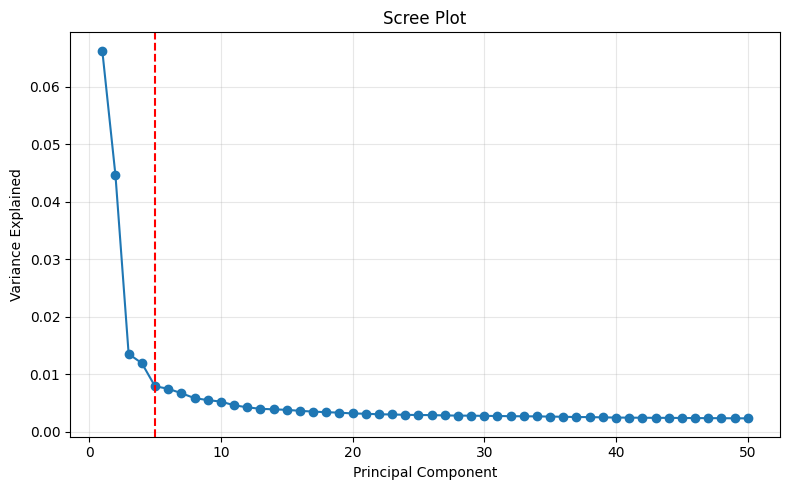

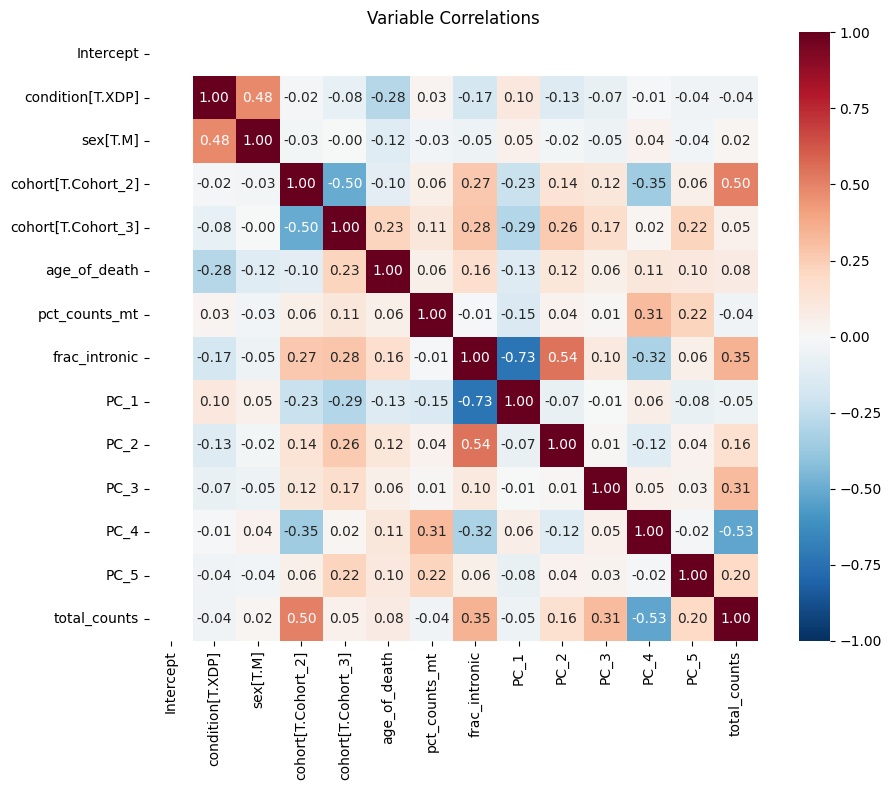

              variable         VIF
0            Intercept  787.687580
7        frac_intronic   10.938932
8                 PC_1    9.904129
3   cohort[T.Cohort_2]    5.764180
4   cohort[T.Cohort_3]    4.745756
9                 PC_2    4.667196
13        total_counts    3.564433
11                PC_4    2.168637
1     condition[T.XDP]    1.450929
10                PC_3    1.441470
2             sex[T.M]    1.343086
6        pct_counts_mt    1.328334
5         age_of_death    1.202522
12                PC_5    1.194182

binary identifiability test. False
Saving qs file...
	Saving files for R coversion...
	Building R obj...

Setting condition reference level to: Control
Levels: Control XDP 
[1] "Creating Seurat object..."


2026-03-27 16:58:15 | [WARNING] R callback write-console: Warning:  
2026-03-27 16:58:15 | [WARNING] R callback write-console:  Data is of class dgTMatrix. Coercing to dgCMatrix.
  


[1] "Saving Seurat object as .qs..."
Running Nebula...
cmd list: ['bash', '/home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh', '--path', '/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/DFC/PCA_nebula/Lamp5/DFC_combined_QC_mmc_ct-cured.qs', '--id-col', 'donor_id', '--offset-col', 'total_counts', '--n-folds', '40', '--n-cores', '40', '--save-tmp', '0']
Running command: bash /home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh --path /home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/DFC/PCA_nebula/Lamp5/DFC_combined_QC_mmc_ct-cured.qs --id-col donor_id --offset-col total_counts --n-folds 40 --n-cores 40 --save-tmp 0
Running command: bash /home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh --path /home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/DFC/PCA_nebula/Lamp5/DFC_combined_QC_mmc_ct-cured.qs --id-col donor_id --offset-col total_counts --n-folds 40 --n-cores 40 --save-tmp 0 --covs condition,age_of_death,sex,pct_counts_mt,

/tmp/ipykernel_3017734/2798495869.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(CONTRAST_VARIABLE)[SAMPLE_VARIABLE]


Scaling
PCA on Healthy
Auto-selected 8 PCs via elbow (17.3% variance explained using 50)
Done.
Running PCA on Diseased...
Normalising


... storing 'ct_for_deg' as categorical


Scaling
PCA on Diseased
Done.
Saving h5ad file...
adata intact: 754 cells, 5674 genes
ATTENTION: Dropping 0 cells with NaN covariates: []
~ condition + age_of_death + sex + pct_counts_mt + frac_intronic + cohort + PC_1 + PC_2 + PC_3 + PC_4 + PC_5 + PC_6 + PC_7 + PC_8 + total_counts


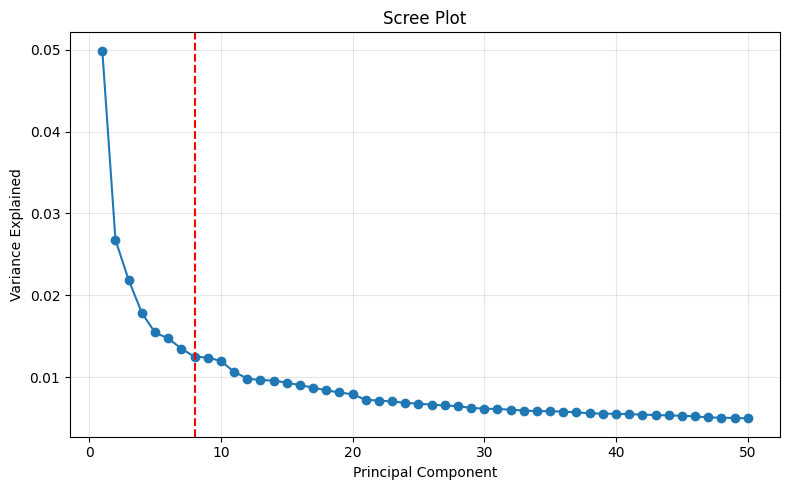

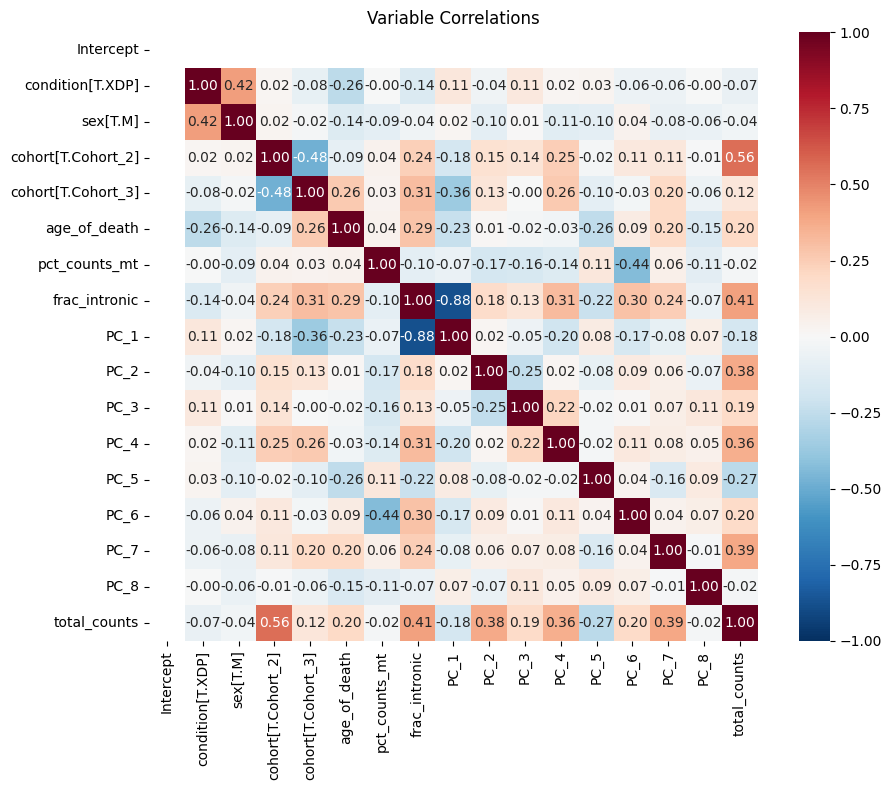

              variable          VIF
0            Intercept  1262.795983
7        frac_intronic    13.384020
8                 PC_1    13.349958
3   cohort[T.Cohort_2]     5.212463
4   cohort[T.Cohort_3]     4.770740
16        total_counts     3.795183
9                 PC_2     2.217120
11                PC_4     2.009107
6        pct_counts_mt     1.625886
14                PC_7     1.530489
13                PC_6     1.528604
10                PC_3     1.449540
2             sex[T.M]     1.405491
5         age_of_death     1.387776
1     condition[T.XDP]     1.350410
12                PC_5     1.330373
15                PC_8     1.074323

binary identifiability test. False
Saving qs file...
	Saving files for R coversion...
	Building R obj...

Setting condition reference level to: Control
Levels: Control XDP 
[1] "Creating Seurat object..."


2026-03-27 16:59:31 | [WARNING] R callback write-console: Warning:  
2026-03-27 16:59:31 | [WARNING] R callback write-console:  Data is of class dgTMatrix. Coercing to dgCMatrix.
  


[1] "Saving Seurat object as .qs..."
Running Nebula...
cmd list: ['bash', '/home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh', '--path', '/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/DFC/PCA_nebula/Lamp5_Lhx6/DFC_combined_QC_mmc_ct-cured.qs', '--id-col', 'donor_id', '--offset-col', 'total_counts', '--n-folds', '40', '--n-cores', '40', '--save-tmp', '0']
Running command: bash /home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh --path /home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/DFC/PCA_nebula/Lamp5_Lhx6/DFC_combined_QC_mmc_ct-cured.qs --id-col donor_id --offset-col total_counts --n-folds 40 --n-cores 40 --save-tmp 0
Running command: bash /home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh --path /home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/DFC/PCA_nebula/Lamp5_Lhx6/DFC_combined_QC_mmc_ct-cured.qs --id-col donor_id --offset-col total_counts --n-folds 40 --n-cores 40 --save-tmp 0 --covs condition,age_of_death,sex

/tmp/ipykernel_3017734/2798495869.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(CONTRAST_VARIABLE)[SAMPLE_VARIABLE]
/tmp/ipykernel_3017734/2798495869.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(CONTRAST_VARIABLE)[SAMPLE_VARIABLE]


Retained donors : 11
Filtered genes  : 38601 -> 806 (min_cells=110, min_counts=50)
ERROR: Too few genes filtered out after gene filtering 


######################
 Microglia 
######################

True
/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/DFC/PCA_nebula/Microglia/DFC_combined_QC_mmc_ct-cured.qs
True
ATTENTION: .X must be raw!
Retained donors : 44
Filtered genes  : 38601 -> 5403 (min_cells=440, min_counts=50)
Running PCA on Healthy...
Normalising
HVG


/tmp/ipykernel_3017734/2798495869.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(CONTRAST_VARIABLE)[SAMPLE_VARIABLE]


Scaling
PCA on Healthy
Auto-selected 8 PCs via elbow (7.3% variance explained using 50)
Done.
Running PCA on Diseased...
Normalising
Scaling
PCA on Diseased
Done.
Saving h5ad file...
adata intact: 5299 cells, 5403 genes
ATTENTION: Dropping 0 cells with NaN covariates: []


... storing 'ct_for_deg' as categorical


~ condition + age_of_death + sex + pct_counts_mt + frac_intronic + cohort + PC_1 + PC_2 + PC_3 + PC_4 + PC_5 + PC_6 + PC_7 + PC_8 + total_counts


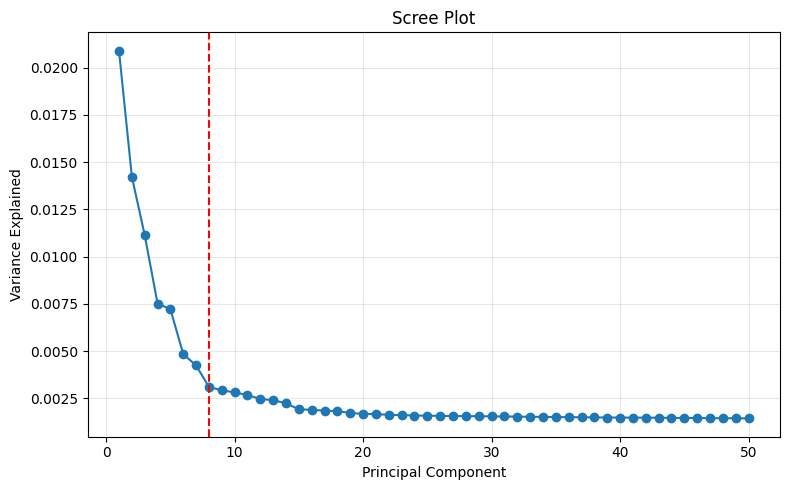

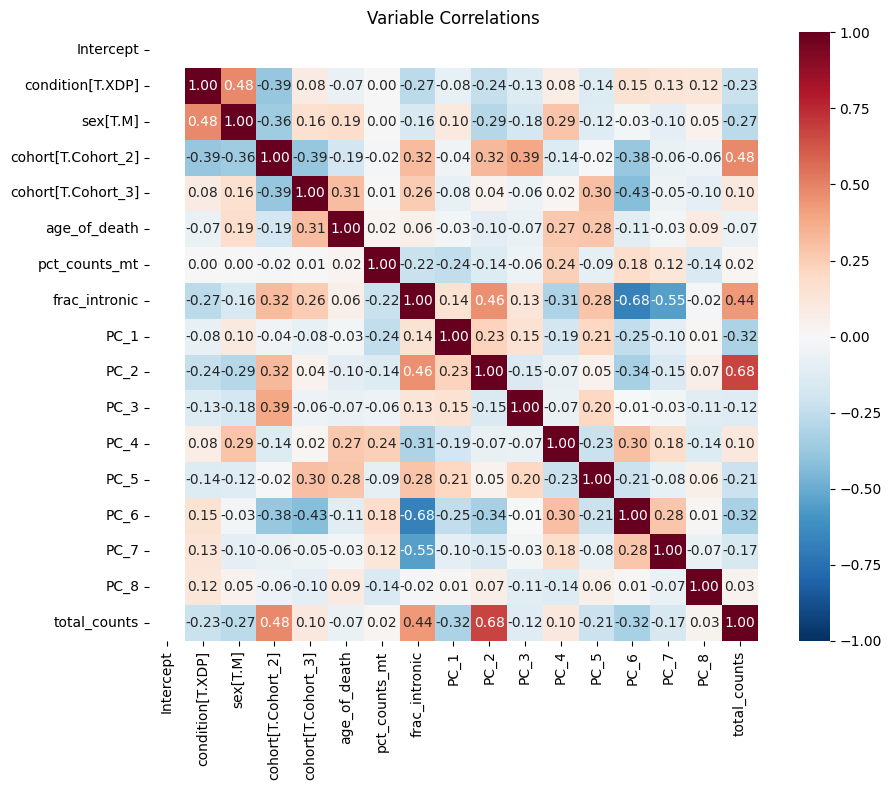

              variable         VIF
0            Intercept  568.670528
3   cohort[T.Cohort_2]    8.732401
13                PC_6    7.441237
16        total_counts    6.309509
4   cohort[T.Cohort_3]    5.871108
7        frac_intronic    4.176798
9                 PC_2    3.912493
8                 PC_1    2.970148
10                PC_3    2.709200
2             sex[T.M]    1.994406
12                PC_5    1.927931
11                PC_4    1.796389
1     condition[T.XDP]    1.708738
14                PC_7    1.703192
5         age_of_death    1.467417
15                PC_8    1.224111
6        pct_counts_mt    1.173523

binary identifiability test. False
Saving qs file...
	Saving files for R coversion...
	Building R obj...

Setting condition reference level to: Control
Levels: Control XDP 
[1] "Creating Seurat object..."


2026-03-27 17:00:38 | [WARNING] R callback write-console: Warning:  
2026-03-27 17:00:38 | [WARNING] R callback write-console:  Data is of class dgTMatrix. Coercing to dgCMatrix.
  


[1] "Saving Seurat object as .qs..."
Running Nebula...
cmd list: ['bash', '/home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh', '--path', '/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/DFC/PCA_nebula/Microglia/DFC_combined_QC_mmc_ct-cured.qs', '--id-col', 'donor_id', '--offset-col', 'total_counts', '--n-folds', '40', '--n-cores', '40', '--save-tmp', '0']
Running command: bash /home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh --path /home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/DFC/PCA_nebula/Microglia/DFC_combined_QC_mmc_ct-cured.qs --id-col donor_id --offset-col total_counts --n-folds 40 --n-cores 40 --save-tmp 0
Running command: bash /home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh --path /home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/DFC/PCA_nebula/Microglia/DFC_combined_QC_mmc_ct-cured.qs --id-col donor_id --offset-col total_counts --n-folds 40 --n-cores 40 --save-tmp 0 --covs condition,age_of_death,sex,pc

/tmp/ipykernel_3017734/2798495869.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(CONTRAST_VARIABLE)[SAMPLE_VARIABLE]


Normalising
HVG
Scaling
PCA on Healthy
Auto-selected 9 PCs via elbow (5.1% variance explained using 50)
Done.
Running PCA on Diseased...
Normalising
Scaling
PCA on Diseased
Done.
Saving h5ad file...
adata intact: 5959 cells, 9793 genes
ATTENTION: Dropping 0 cells with NaN covariates: []


... storing 'ct_for_deg' as categorical


~ condition + age_of_death + sex + pct_counts_mt + frac_intronic + cohort + PC_1 + PC_2 + PC_3 + PC_4 + PC_5 + PC_6 + PC_7 + PC_8 + PC_9 + total_counts


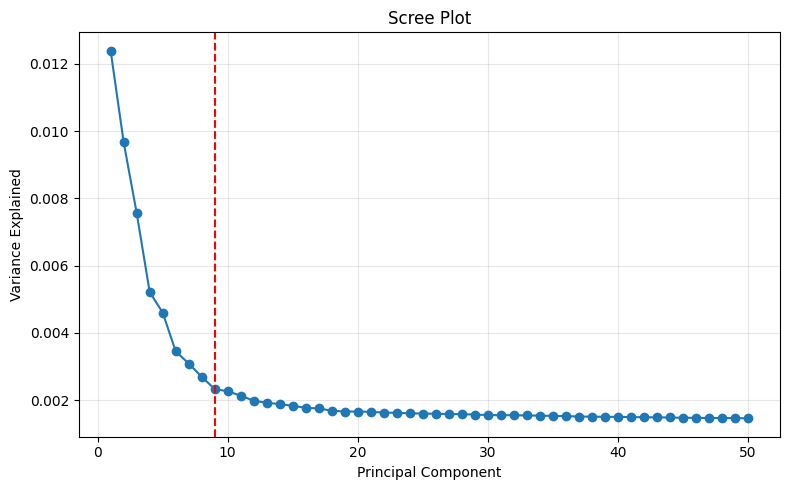

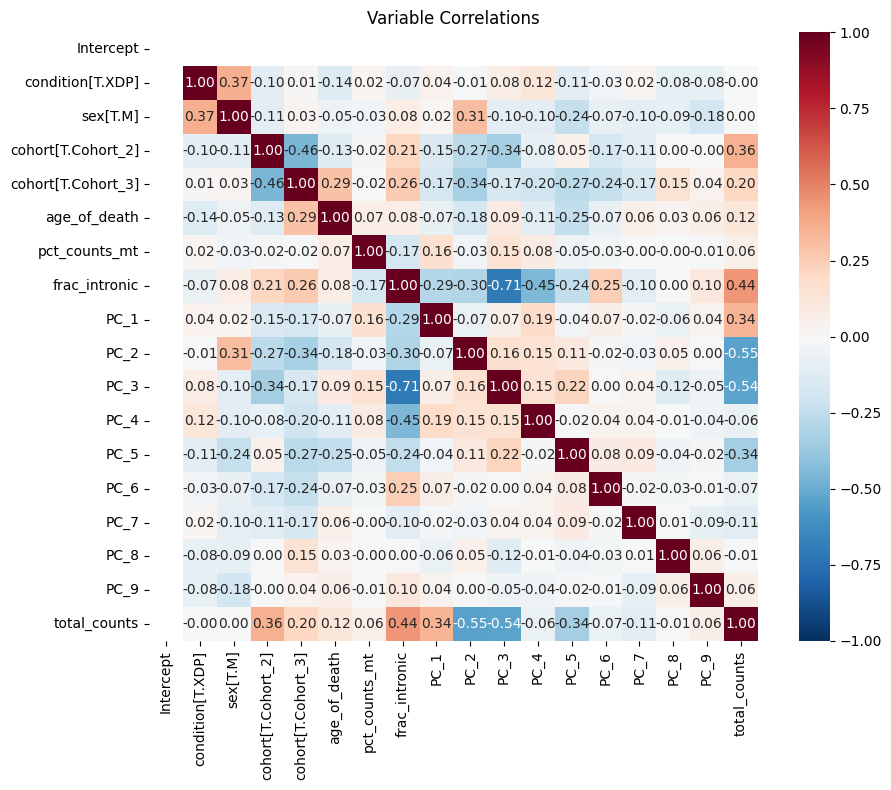

              variable         VIF
0            Intercept  863.455222
4   cohort[T.Cohort_3]    7.361872
3   cohort[T.Cohort_2]    7.240704
7        frac_intronic    5.132718
10                PC_3    3.878001
17        total_counts    3.847116
9                 PC_2    3.728249
8                 PC_1    3.074865
13                PC_6    2.337688
2             sex[T.M]    1.673007
11                PC_4    1.627974
14                PC_7    1.595775
12                PC_5    1.396001
1     condition[T.XDP]    1.336775
5         age_of_death    1.301356
15                PC_8    1.172730
16                PC_9    1.109451
6        pct_counts_mt    1.082992

binary identifiability test. False
Saving qs file...
	Saving files for R coversion...
	Building R obj...

Setting condition reference level to: Control
Levels: Control XDP 
[1] "Creating Seurat object..."


2026-03-27 17:02:08 | [WARNING] R callback write-console: Warning:  
2026-03-27 17:02:08 | [WARNING] R callback write-console:  Data is of class dgTMatrix. Coercing to dgCMatrix.
  


[1] "Saving Seurat object as .qs..."
Running Nebula...
cmd list: ['bash', '/home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh', '--path', '/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/DFC/PCA_nebula/OPC/DFC_combined_QC_mmc_ct-cured.qs', '--id-col', 'donor_id', '--offset-col', 'total_counts', '--n-folds', '40', '--n-cores', '40', '--save-tmp', '0']
Running command: bash /home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh --path /home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/DFC/PCA_nebula/OPC/DFC_combined_QC_mmc_ct-cured.qs --id-col donor_id --offset-col total_counts --n-folds 40 --n-cores 40 --save-tmp 0
Running command: bash /home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh --path /home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/DFC/PCA_nebula/OPC/DFC_combined_QC_mmc_ct-cured.qs --id-col donor_id --offset-col total_counts --n-folds 40 --n-cores 40 --save-tmp 0 --covs condition,age_of_death,sex,pct_counts_mt,frac_i

/tmp/ipykernel_3017734/2798495869.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(CONTRAST_VARIABLE)[SAMPLE_VARIABLE]


Normalising
HVG
Scaling
PCA on Healthy
Auto-selected 5 PCs via elbow (6.8% variance explained using 50)
Done.
Running PCA on Diseased...
Normalising
Scaling
PCA on Diseased
Done.
Saving h5ad file...
adata intact: 36843 cells, 12611 genes
ATTENTION: Dropping 0 cells with NaN covariates: []


... storing 'ct_for_deg' as categorical


~ condition + age_of_death + sex + pct_counts_mt + frac_intronic + cohort + PC_1 + PC_2 + PC_3 + PC_4 + PC_5 + total_counts


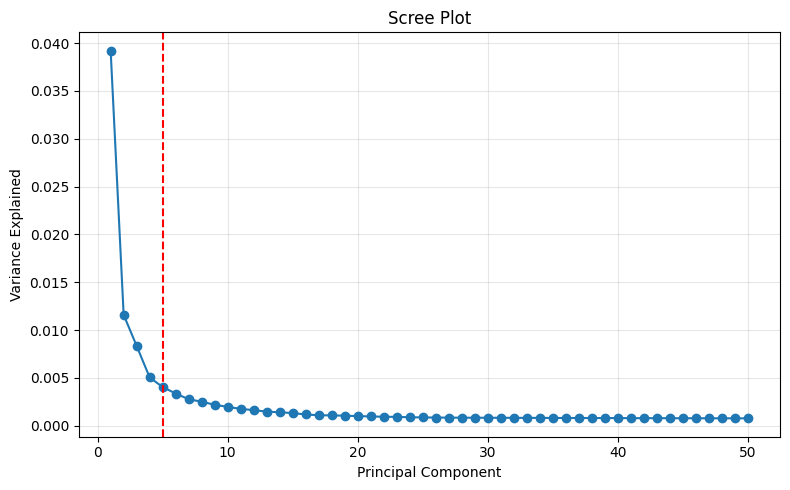

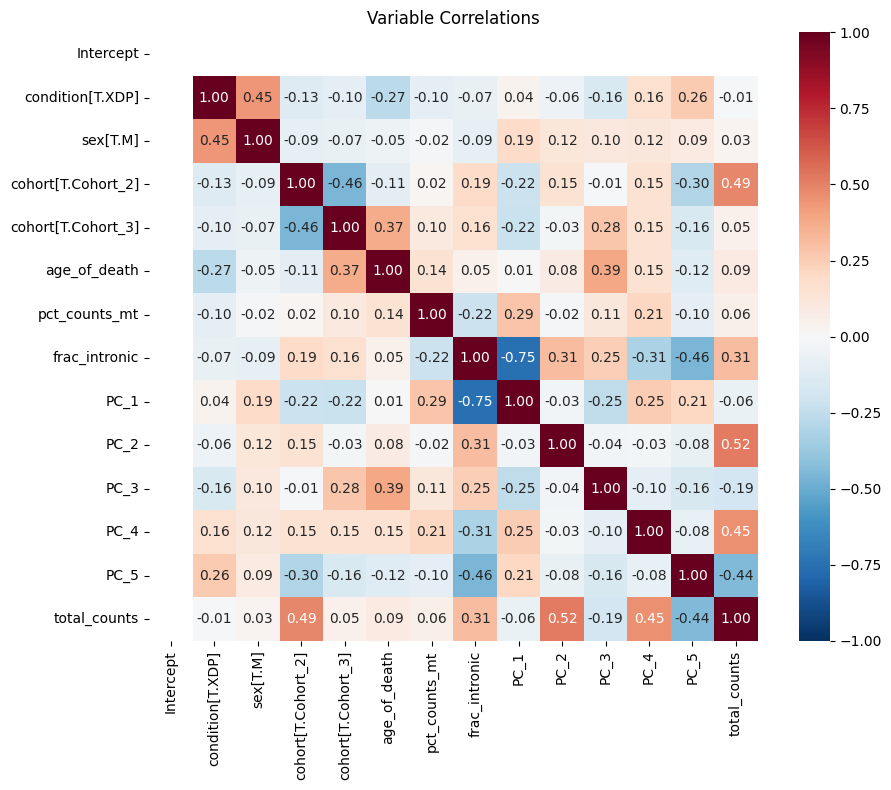

              variable         VIF
0            Intercept  463.984231
7        frac_intronic    5.005689
13        total_counts    4.645079
8                 PC_1    3.981809
3   cohort[T.Cohort_2]    3.175263
4   cohort[T.Cohort_3]    2.576476
11                PC_4    2.278524
12                PC_5    2.006515
9                 PC_2    1.935946
10                PC_3    1.791424
1     condition[T.XDP]    1.647859
5         age_of_death    1.479247
2             sex[T.M]    1.463414
6        pct_counts_mt    1.234785

binary identifiability test. False
Saving qs file...
	Saving files for R coversion...
	Building R obj...

Setting condition reference level to: Control
Levels: Control XDP 
[1] "Creating Seurat object..."


2026-03-27 17:05:08 | [WARNING] R callback write-console: Warning:  
2026-03-27 17:05:08 | [WARNING] R callback write-console:  Data is of class dgTMatrix. Coercing to dgCMatrix.
  


[1] "Saving Seurat object as .qs..."
Running Nebula...
cmd list: ['bash', '/home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh', '--path', '/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/DFC/PCA_nebula/Oligodendrocyte/DFC_combined_QC_mmc_ct-cured.qs', '--id-col', 'donor_id', '--offset-col', 'total_counts', '--n-folds', '40', '--n-cores', '40', '--save-tmp', '0']
Running command: bash /home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh --path /home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/DFC/PCA_nebula/Oligodendrocyte/DFC_combined_QC_mmc_ct-cured.qs --id-col donor_id --offset-col total_counts --n-folds 40 --n-cores 40 --save-tmp 0
Running command: bash /home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh --path /home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/DFC/PCA_nebula/Oligodendrocyte/DFC_combined_QC_mmc_ct-cured.qs --id-col donor_id --offset-col total_counts --n-folds 40 --n-cores 40 --save-tmp 0 --covs condition,a

/tmp/ipykernel_3017734/2798495869.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(CONTRAST_VARIABLE)[SAMPLE_VARIABLE]
/tmp/ipykernel_3017734/2798495869.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(CONTRAST_VARIABLE)[SAMPLE_VARIABLE]


True
/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/DFC/PCA_nebula/Pvalb/DFC_combined_QC_mmc_ct-cured.qs
True
ATTENTION: .X must be raw!
Retained donors : 44
Filtered genes  : 38601 -> 13478 (min_cells=440, min_counts=50)
Running PCA on Healthy...


/tmp/ipykernel_3017734/2798495869.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(CONTRAST_VARIABLE)[SAMPLE_VARIABLE]


Normalising
HVG
Scaling
PCA on Healthy
Auto-selected 4 PCs via elbow (9.0% variance explained using 50)
Done.
Running PCA on Diseased...
Normalising
Scaling
PCA on Diseased
Done.
Saving h5ad file...
adata intact: 5403 cells, 13478 genes
ATTENTION: Dropping 0 cells with NaN covariates: []


... storing 'ct_for_deg' as categorical


~ condition + age_of_death + sex + pct_counts_mt + frac_intronic + cohort + PC_1 + PC_2 + PC_3 + PC_4 + total_counts


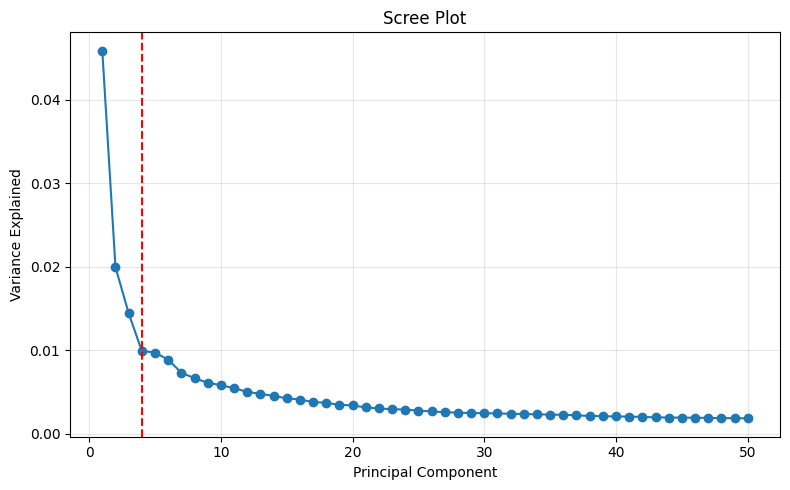

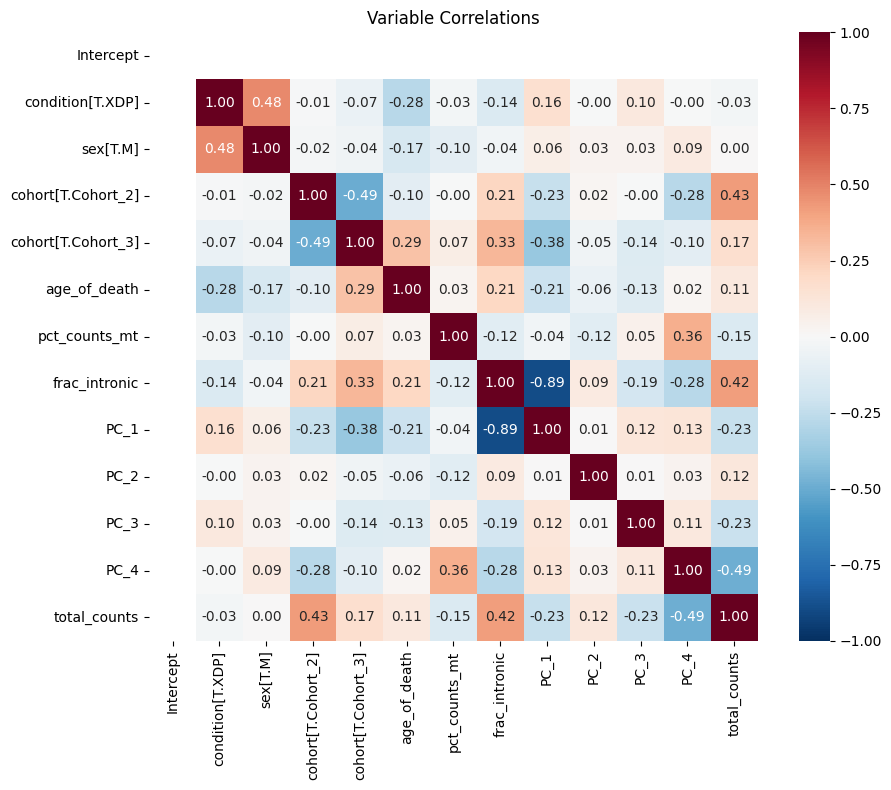

              variable         VIF
0            Intercept  803.666934
8                 PC_1   10.018491
7        frac_intronic    9.010289
3   cohort[T.Cohort_2]    3.672164
4   cohort[T.Cohort_3]    3.345484
12        total_counts    2.702499
11                PC_4    1.744767
1     condition[T.XDP]    1.408072
2             sex[T.M]    1.362917
6        pct_counts_mt    1.312046
5         age_of_death    1.222620
10                PC_3    1.094261
9                 PC_2    1.093253

binary identifiability test. False
Saving qs file...
	Saving files for R coversion...
	Building R obj...

Setting condition reference level to: Control
Levels: Control XDP 
[1] "Creating Seurat object..."


2026-03-27 17:11:53 | [WARNING] R callback write-console: Warning:  
2026-03-27 17:11:53 | [WARNING] R callback write-console:  Data is of class dgTMatrix. Coercing to dgCMatrix.
  


[1] "Saving Seurat object as .qs..."
Running Nebula...
cmd list: ['bash', '/home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh', '--path', '/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/DFC/PCA_nebula/Pvalb/DFC_combined_QC_mmc_ct-cured.qs', '--id-col', 'donor_id', '--offset-col', 'total_counts', '--n-folds', '40', '--n-cores', '40', '--save-tmp', '0']
Running command: bash /home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh --path /home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/DFC/PCA_nebula/Pvalb/DFC_combined_QC_mmc_ct-cured.qs --id-col donor_id --offset-col total_counts --n-folds 40 --n-cores 40 --save-tmp 0
Running command: bash /home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh --path /home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/DFC/PCA_nebula/Pvalb/DFC_combined_QC_mmc_ct-cured.qs --id-col donor_id --offset-col total_counts --n-folds 40 --n-cores 40 --save-tmp 0 --covs condition,age_of_death,sex,pct_counts_mt,

/tmp/ipykernel_3017734/2798495869.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(CONTRAST_VARIABLE)[SAMPLE_VARIABLE]


True
/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/DFC/PCA_nebula/Sncg/DFC_combined_QC_mmc_ct-cured.qs
True
ATTENTION: .X must be raw!
Dropping 2 donor(s) with < 10 cells:
  SCF_22-043                      n_cells=   7  condition=XDP
  SCF_22_067CM                    n_cells=   8  condition=Control
Retained donors : 42
Filtered genes  : 38601 -> 8665 (min_cells=420, min_counts=50)
Running PCA on Healthy...
Normalising
HVG


/tmp/ipykernel_3017734/2798495869.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(CONTRAST_VARIABLE)[SAMPLE_VARIABLE]


Scaling
PCA on Healthy
Auto-selected 7 PCs via elbow (15.3% variance explained using 50)
Done.
Running PCA on Diseased...
Normalising
Scaling
PCA on Diseased
Done.
Saving h5ad file...
adata intact: 1925 cells, 8665 genes
ATTENTION: Dropping 0 cells with NaN covariates: []


... storing 'ct_for_deg' as categorical


~ condition + age_of_death + sex + pct_counts_mt + frac_intronic + cohort + PC_1 + PC_2 + PC_3 + PC_4 + PC_5 + PC_6 + PC_7 + total_counts


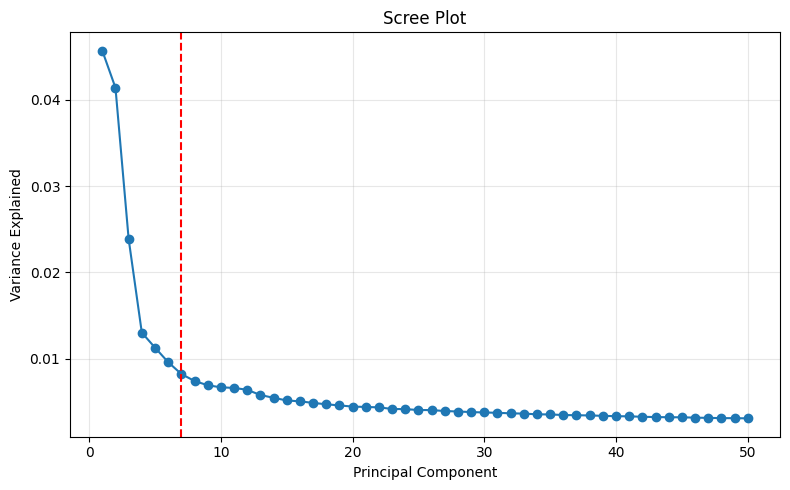

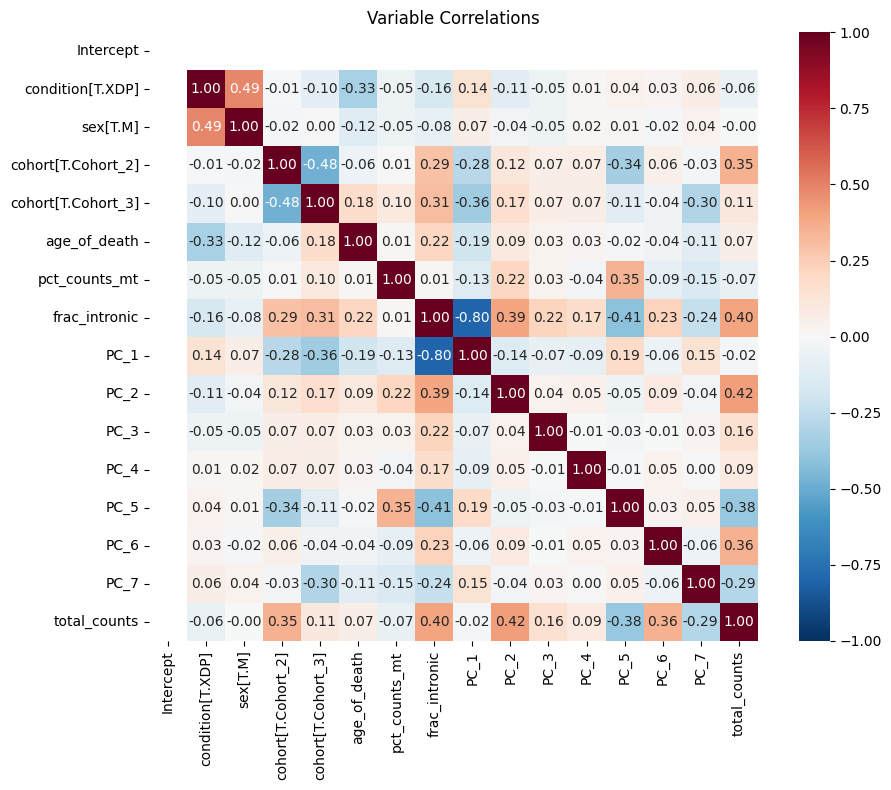

              variable         VIF
0            Intercept  876.967336
7        frac_intronic   11.336652
8                 PC_1   10.751005
3   cohort[T.Cohort_2]    4.592650
4   cohort[T.Cohort_3]    4.296209
15        total_counts    3.221681
12                PC_5    2.628083
9                 PC_2    2.007420
14                PC_7    1.489147
1     condition[T.XDP]    1.476850
13                PC_6    1.408004
6        pct_counts_mt    1.370409
10                PC_3    1.339484
2             sex[T.M]    1.335828
5         age_of_death    1.197346
11                PC_4    1.154940

binary identifiability test. False
Saving qs file...
	Saving files for R coversion...
	Building R obj...

Setting condition reference level to: Control
Levels: Control XDP 
[1] "Creating Seurat object..."


2026-03-27 17:13:44 | [WARNING] R callback write-console: Warning:  
2026-03-27 17:13:44 | [WARNING] R callback write-console:  Data is of class dgTMatrix. Coercing to dgCMatrix.
  


[1] "Saving Seurat object as .qs..."
Running Nebula...
cmd list: ['bash', '/home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh', '--path', '/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/DFC/PCA_nebula/Sncg/DFC_combined_QC_mmc_ct-cured.qs', '--id-col', 'donor_id', '--offset-col', 'total_counts', '--n-folds', '40', '--n-cores', '40', '--save-tmp', '0']
Running command: bash /home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh --path /home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/DFC/PCA_nebula/Sncg/DFC_combined_QC_mmc_ct-cured.qs --id-col donor_id --offset-col total_counts --n-folds 40 --n-cores 40 --save-tmp 0
Running command: bash /home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh --path /home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/DFC/PCA_nebula/Sncg/DFC_combined_QC_mmc_ct-cured.qs --id-col donor_id --offset-col total_counts --n-folds 40 --n-cores 40 --save-tmp 0 --covs condition,age_of_death,sex,pct_counts_mt,fra

/tmp/ipykernel_3017734/2798495869.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(CONTRAST_VARIABLE)[SAMPLE_VARIABLE]


Normalising
HVG
Scaling
PCA on Healthy
Auto-selected 6 PCs via elbow (9.9% variance explained using 50)
Done.
Running PCA on Diseased...
Normalising
Scaling
PCA on Diseased
Done.
Saving h5ad file...
adata intact: 6014 cells, 11517 genes
ATTENTION: Dropping 0 cells with NaN covariates: []


... storing 'ct_for_deg' as categorical


~ condition + age_of_death + sex + pct_counts_mt + frac_intronic + cohort + PC_1 + PC_2 + PC_3 + PC_4 + PC_5 + PC_6 + total_counts


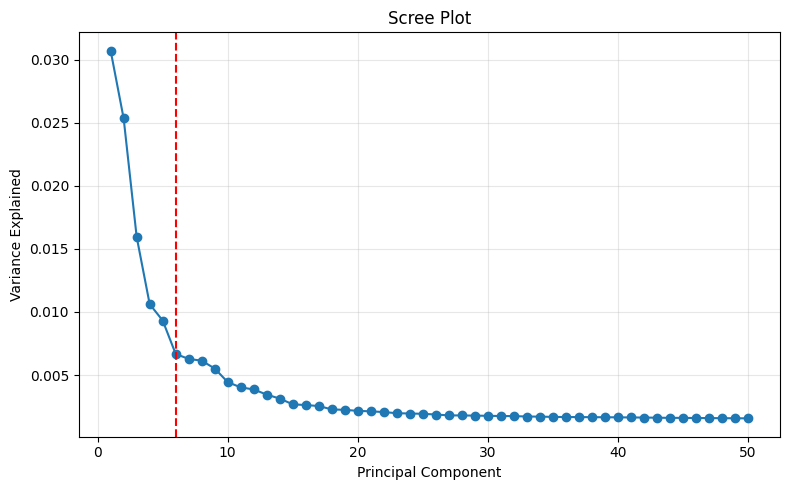

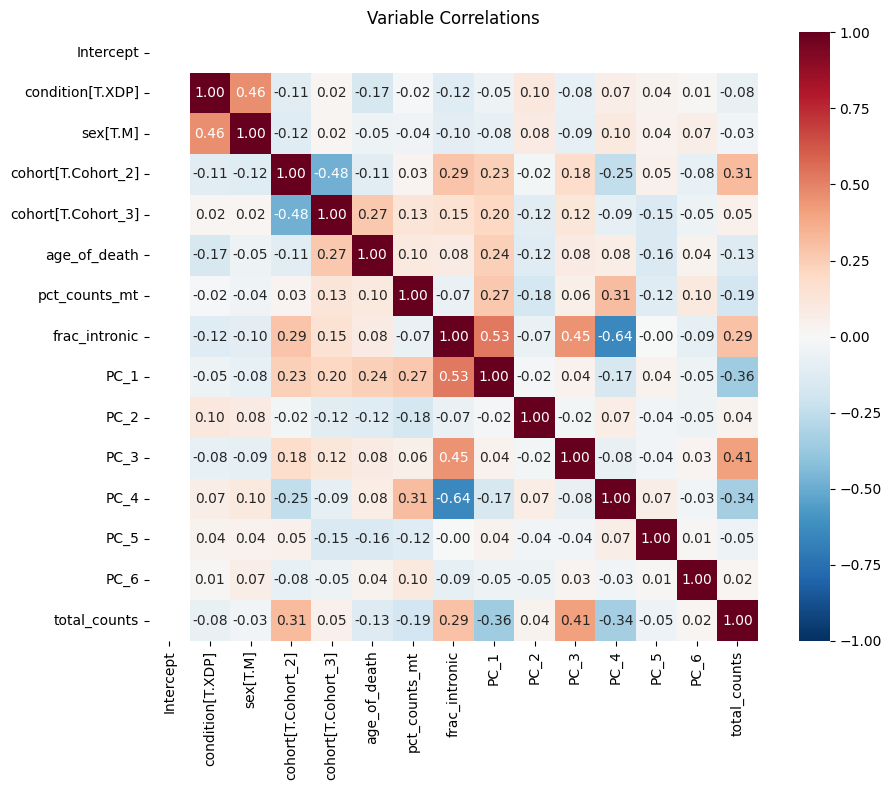

              variable         VIF
0            Intercept  572.923426
7        frac_intronic    5.154719
8                 PC_1    4.574671
14        total_counts    3.132077
3   cohort[T.Cohort_2]    3.048859
11                PC_4    2.876878
4   cohort[T.Cohort_3]    2.578984
10                PC_3    1.924937
6        pct_counts_mt    1.440829
1     condition[T.XDP]    1.341050
2             sex[T.M]    1.318941
5         age_of_death    1.246159
13                PC_6    1.172504
9                 PC_2    1.157665
12                PC_5    1.109911

binary identifiability test. False
Saving qs file...
	Saving files for R coversion...
	Building R obj...

Setting condition reference level to: Control
Levels: Control XDP 
[1] "Creating Seurat object..."


2026-03-27 17:15:09 | [WARNING] R callback write-console: Warning:  
2026-03-27 17:15:09 | [WARNING] R callback write-console:  Data is of class dgTMatrix. Coercing to dgCMatrix.
  


[1] "Saving Seurat object as .qs..."
Running Nebula...
cmd list: ['bash', '/home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh', '--path', '/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/DFC/PCA_nebula/Sst/DFC_combined_QC_mmc_ct-cured.qs', '--id-col', 'donor_id', '--offset-col', 'total_counts', '--n-folds', '40', '--n-cores', '40', '--save-tmp', '0']
Running command: bash /home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh --path /home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/DFC/PCA_nebula/Sst/DFC_combined_QC_mmc_ct-cured.qs --id-col donor_id --offset-col total_counts --n-folds 40 --n-cores 40 --save-tmp 0
Running command: bash /home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh --path /home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/DFC/PCA_nebula/Sst/DFC_combined_QC_mmc_ct-cured.qs --id-col donor_id --offset-col total_counts --n-folds 40 --n-cores 40 --save-tmp 0 --covs condition,age_of_death,sex,pct_counts_mt,frac_i

/tmp/ipykernel_3017734/2798495869.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(CONTRAST_VARIABLE)[SAMPLE_VARIABLE]


Normalising
HVG
Scaling
PCA on Healthy
Auto-selected 7 PCs via elbow (12.6% variance explained using 50)
Done.
Running PCA on Diseased...
Normalising
Scaling
PCA on Diseased
Done.
Saving h5ad file...
adata intact: 5479 cells, 13038 genes
ATTENTION: Dropping 0 cells with NaN covariates: []


... storing 'ct_for_deg' as categorical


~ condition + age_of_death + sex + pct_counts_mt + frac_intronic + cohort + PC_1 + PC_2 + PC_3 + PC_4 + PC_5 + PC_6 + PC_7 + total_counts


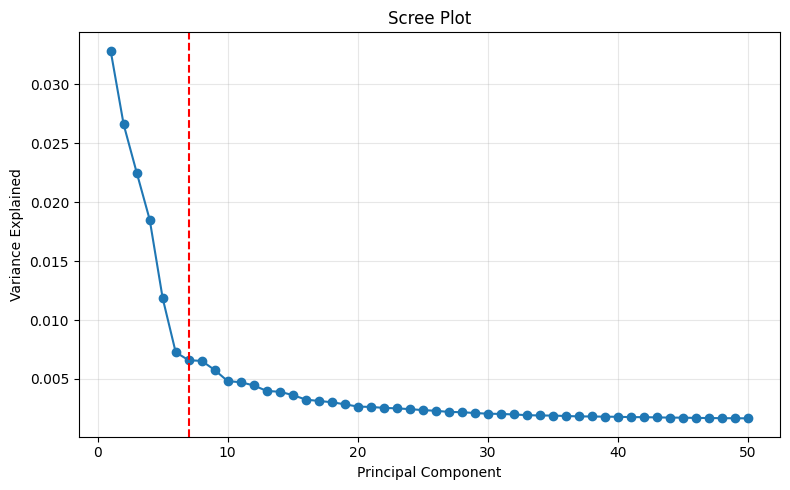

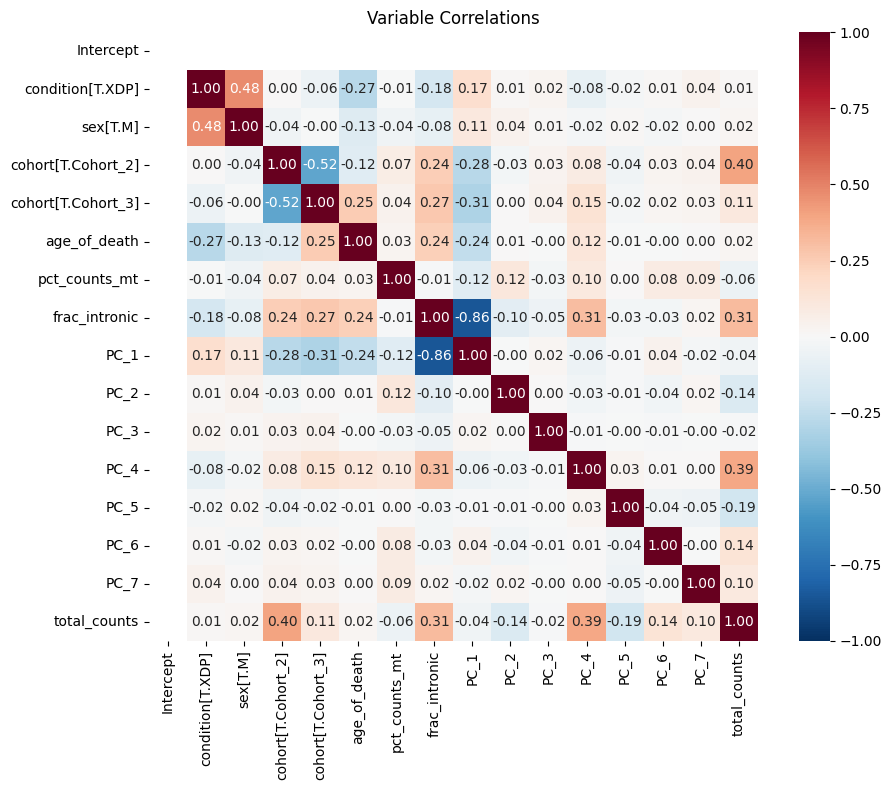

              variable         VIF
0            Intercept  674.221202
8                 PC_1   11.023600
7        frac_intronic    8.810690
3   cohort[T.Cohort_2]    4.408616
4   cohort[T.Cohort_3]    3.563924
15        total_counts    3.215143
11                PC_4    1.558993
1     condition[T.XDP]    1.403895
2             sex[T.M]    1.309631
5         age_of_death    1.198662
6        pct_counts_mt    1.155088
9                 PC_2    1.066487
12                PC_5    1.062035
13                PC_6    1.041738
10                PC_3    1.028360
14                PC_7    1.026206

binary identifiability test. False
Saving qs file...
	Saving files for R coversion...
	Building R obj...

Setting condition reference level to: Control
Levels: Control XDP 
[1] "Creating Seurat object..."


2026-03-27 17:17:16 | [WARNING] R callback write-console: Warning:  
2026-03-27 17:17:16 | [WARNING] R callback write-console:  Data is of class dgTMatrix. Coercing to dgCMatrix.
  


[1] "Saving Seurat object as .qs..."
Running Nebula...
cmd list: ['bash', '/home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh', '--path', '/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/DFC/PCA_nebula/Vip/DFC_combined_QC_mmc_ct-cured.qs', '--id-col', 'donor_id', '--offset-col', 'total_counts', '--n-folds', '40', '--n-cores', '40', '--save-tmp', '0']
Running command: bash /home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh --path /home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/DFC/PCA_nebula/Vip/DFC_combined_QC_mmc_ct-cured.qs --id-col donor_id --offset-col total_counts --n-folds 40 --n-cores 40 --save-tmp 0
Running command: bash /home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh --path /home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/DFC/PCA_nebula/Vip/DFC_combined_QC_mmc_ct-cured.qs --id-col donor_id --offset-col total_counts --n-folds 40 --n-cores 40 --save-tmp 0 --covs condition,age_of_death,sex,pct_counts_mt,frac_i

In [14]:
for ct in sorted(adata.obs[CT_FOR_DEG_VARIABLE].unique().tolist())[:]:

    #ct="Matrix_D1"
    if "-" in ct:
        continue
    print("\n\n######################\n",ct, "\n######################\n")

    # Select single ct
    adata_ct = adata[adata.obs[CT_FOR_DEG_VARIABLE] == ct].to_memory().copy()
    adata_ct.X = adata_ct.layers["counts"].copy() 
    print(np.array_equal(adata_ct.X.data, adata_ct.X.data.astype(int)) if hasattr(adata_ct.X, 'data') else np.array_equal(adata_ct.X, adata_ct.X.astype(int)))

    # adata_ct = adata_ct[adata_ct.obs["zone"].isin(["4"])].copy() # only keep control and XDP for this analsys
    # print(adata_ct)

    # Define saving apthjs
    ADATA_PATH_QS = f"{DEG_FOLDER}/{ct}/{os.path.splitext(os.path.basename(ADATA_PATH))[0]}.qs"
    SAVE_HEALTHY_PCA_RESULT = os.path.dirname(ADATA_PATH_QS)
    os.makedirs(SAVE_HEALTHY_PCA_RESULT, exist_ok=True)
    print(ADATA_PATH_QS)

    #break

    # Run enire pipeline for this ct
    run_nebula_with_PCs(
        adata_ct, 
        ADATA_PATH_QS, SAVE_HEALTHY_PCA_RESULT, PARALLEL_NEBULA_SCRIPT_PATH,
        CONTRAST_VARIABLE,CONTRAST_BASELINE, CONTRAST_STIM,
        SAMPLE_VARIABLE,LIBRARY_SIZE_COL,COVARIATES_FOR_DEG,
        N_PCS_TO_USE=None, variance_threshold=None,delete_tmp_files=True, TYPE_DEG=TYPE_DEG,
        MIN_SAMPLES_PER_CONDITION=4, MIN_NUMBER_GENES_PER_ANALYSIS=3000
    )

    #break

In [43]:
adata.obs[adata.obs[CONTRAST_VARIABLE].isna()][SAMPLE_VARIABLE].unique()

['SCF_21_036B']
Categories (45, object): ['PCMC-16-011', 'PCMC-16-012', 'SCF-18-003', 'SCF-18-004', ..., 'SCF_23_072CF', 'SCF_23_074CF', 'SCF_23_075CM', 'SCF_23_079CF']

# Tun for all Zones (ONLY STR)

In [ ]:
# Map: cell types that have zone analysis → their zone variable
# each cell type has  a better zonation level
ZONE_CT_MAP = {
    "Matrix_D1": "zone", # just zone for zone_6
    "Matrix_D2": "zone",

    "Patch_D1":  "zone_4",
    "Patch_D2":  "zone_4",
    "eMSN_D1D2": "zone_4",
    "Astrocyte": "zone_4",
}
# adata stays untouched here — no more global mutation


In [ ]:
for zone_ct, zone_variable in ZONE_CT_MAP.items():
    
    if zone_ct not in adata.obs["ct_for_deg"].values:
        print(f"WARNING: {zone_ct} not in adata, skipping")
        continue

    adata_zone = adata[
        (adata.obs["ct_for_deg"] == zone_ct) & # filter to QC labels
        (adata.obs[zone_variable].notna()) # only cells with zone annotation
    ].to_memory().copy()

    for zone in sorted(adata_zone.obs[zone_variable].unique()):
        print(f"\n\n######################\n{zone_ct} / {zone_variable}={zone} / {TYPE_DEG}\n######################\n")

        adata_ct = adata_zone[adata_zone.obs[zone_variable] == zone].to_memory().copy()
        adata_ct.X = adata_ct.layers["counts"].copy()

        subfolder = f"{zone_ct}_by_{zone_variable}/{zone}"
        ADATA_PATH_QS = f"{DEG_FOLDER}/{subfolder}/{os.path.splitext(os.path.basename(ADATA_PATH))[0]}.qs"
        SAVE_HEALTHY_PCA_RESULT = os.path.dirname(ADATA_PATH_QS)
        os.makedirs(SAVE_HEALTHY_PCA_RESULT, exist_ok=True)
        print(SAVE_HEALTHY_PCA_RESULT)

        run_nebula_with_PCs(
            adata_ct,
            ADATA_PATH_QS, SAVE_HEALTHY_PCA_RESULT, PARALLEL_NEBULA_SCRIPT_PATH,
            CONTRAST_VARIABLE, CONTRAST_BASELINE, CONTRAST_STIM,
            SAMPLE_VARIABLE, LIBRARY_SIZE_COL, COVARIATES_FOR_DEG,
            N_PCS_TO_USE=None, variance_threshold=None, delete_tmp_files=True, TYPE_DEG=TYPE_DEG,
            MIN_SAMPLES_PER_CONDITION=4, MIN_NUMBER_GENES_PER_ANALYSIS=3000
        )


# Plot Results

In [ ]:
JJJJ

In [ ]:
# PVAL_COL=f"p_{CONTRAST_VARIABLE}{CONTRAST_STIM}"
# LOGFC_COL=f"logFC_{CONTRAST_VARIABLE}{CONTRAST_STIM}"
# SE_COL=f"se_{CONTRAST_VARIABLE}{CONTRAST_STIM}"
# GENE_COL="gene"
# PVAL_THR=0.05
# THR_FDR_GSEA=0.05
# LOGFC_THR=0.5 #1e-30#0.5 #set your logFC threshold at or above the median SE
# perform_gsea = True

# from statsmodels.stats.multitest import multipletests
# import gseapy as gp
# from gseapy import dotplot, barplot, gseaplot2
# print(gp.get_library_name())

# df_sig_all = {}
# saved_figs = {}

# for ct in sorted(adata.obs[CT_FOR_DEG_VARIABLE].unique().tolist()):

#     ct="Matrix"
#     if "-" in ct:
#         continue
#     print("\n######################\n",ct, "\n######################\n")

#     subfolder = f"{ZONE_CT}_by_zone/{ct}" if RUN_ON_ZONES else ct         # subfolder changes depending on mode
#     SAVE_HEALTHY_PCA_RESULT = f"{DEG_FOLDER}/{subfolder}"
    
#     save_csv_path = f"{SAVE_HEALTHY_PCA_RESULT}/deg_results.csv"
#     formatted_save_csv_path = f"{SAVE_HEALTHY_PCA_RESULT}/deg_results_formatted.csv"
#     vulcano_plot_path = f"{SAVE_HEALTHY_PCA_RESULT}/volcano_plot.png"

#     if not os.path.exists(save_csv_path):
#         print(f"ERROR: Missing results file for {ct} at {save_csv_path}")
#         continue

#     # Read results nebula
#     df_nebula = pd.read_csv(save_csv_path)

#     # Add adj pvalue
#     # attention: use all genes
#     col_p_adj = f"adj_{PVAL_COL}"
#     df_nebula = df_nebula.dropna(subset=[PVAL_COL, LOGFC_COL])
#     df_nebula[col_p_adj] = multipletests(df_nebula[PVAL_COL],method="fdr_bh")[1]

#     # Add gradient info
#     df_nebula = df_nebula.merge(df_grad, how="left", left_on=GENE_COL, right_index=True)
#     df_nebula["is_grad_gene"] = df_nebula["gene"].isin(grad_genes)
#     df_nebula = df_nebula.sort_values(col_p_adj)

#     # save fomatted
#     #.to_csv(formatted_save_csv_path, index=False)

#     # Selec signficant genes
#     sig_genes = df_nebula[(np.abs(df_nebula[LOGFC_COL]) >= LOGFC_THR) & (df_nebula[col_p_adj] <= PVAL_THR)][GENE_COL].tolist()
#     df_sig = df_nebula[df_nebula[GENE_COL].isin(sig_genes)].copy()
#     df_sig = df_sig[[GENE_COL, LOGFC_COL, col_p_adj, "is_grad_gene", "mean_spearman"]]
#     print(df_sig[GENE_COL].to_list())
#     display(df_sig)
#     print(df_sig["is_grad_gene"].sum())

#     # Save top and bottom singinccat genes
#     N_TOP_GENES=20
#     df_sig_all[ct] = {
#         "up":   df_sig.sort_values([col_p_adj, LOGFC_COL], ascending=[True, False]).head(N_TOP_GENES),
#         "down": df_sig.sort_values([col_p_adj, LOGFC_COL], ascending=[True, True]).head(N_TOP_GENES),
#     }

#     #########
#     ### VULCANO PLOT
#     ##########
#     categories_spatial = {"Spatial Gradient Genes": (grad_genes, "green"),}
#     categories_age = {"Age Genes": (["HCN1", "VWC2", "OPRM1", "BACH2", "PCED1B", "MME", "EBF1", "SPON1", "SEMA3E", "SERPINE2", "LINGO2", "GRM8", "KCNK2", "SINHCAF", "DDIT4L", "PTPN7", "PRKD1", "PEX5L", "OPCML", "SHC3", "PDE4B", "SLC24A2", "CCDC39", "FAT2", "CNTN5", "FIGN", "PTPRT", "MGAT4C", "IGF2BP2", "AR", "ETV1", "CDH10", "CORO1C", "SPRED2", "GJD2-DT", "ST3GAL6", "EPHA3", "UBASH3B", "PLEKHA7", "PLD5", "SH3RF3", "DOK5", "DOCK10", "SEMA3D", "KITLG", "SCN11A", "COL19A1", "ZNF732", "UNC13C", "SATB1"], "blue"),}
#     categories_general = {
#         "TAF1 related genes": (["TAF1", "TIA1", "ZNF772", "SMG7", "ZNF93", "MOV10L1", "EXO1"], "red"),
#         "Old significant genes": (["SLC7A2", "FKBP5", "ZBTB16", "HIF3A", "NR3C1"], "blue"),
#         "Could relate to XDP": (
#                             [
#                             # Primary disease locus genes (Xq13.1)
#                             "TAF1", "OGT", "ACRC", "CXCR3", "NONO", "ING2", "NLGN3", "GJB1", "ZNF261", "ITGB1BP2",
                            
#                             # Direct TAF1 protein interactors (TFIID complex)
#                             "TBP", "TAF2", "TAF3", "TAF4", "TAF5", "TAF6", "TAF7", "TAF8", "TAF9", "TAF10", "TAF11", "TAF12", "TAF13",
                            
#                             # TAF1 kinase/ubiquitin substrates and binding partners
#                             "TP53", "MDM2", "RB1", "AR", "JUN", "CCND1", "CCNA2",
                            
#                             # General Transcription Factors (PIC assembly)
#                             "GTF2B", "GTF2A1", "GTF2A2", "GTF2E1", "GTF2E2", "GTF2F1", "GTF2F2", "GTF2H1", "GTF2H2", "GTF2H3", "GTF2H4", "GTF2H5", "TCEA1", "ERCC2", "ERCC3",
                            
#                             # TAF1 in MLL1 complex
#                             "KMT2A", "ASH2L", "HCFC1", "WDR5", "RBBP5",
                            
#                             # Striatal signaling breakdown (dysregulated in XDP brain)
#                             "DRD2", "DRD1", "PDE10A", "GNAL",
                            
#                             # DSC3-affected downstream genes (vesicular transport, dopamine, synapse)
#                             "SYP", "SNAP25", "RAB26", "RAB27B", "RAB8B", "DDC", "GCH1", "SLC18A2", "SYT7", "DLG4", "SNAP91", "DBH", "SYTL2", "SLC5A3", "EFNB1",
                            
#                             # NFkB pathway and inflammatory targets (altered in XDP fibroblasts)
#                             "RELA", "NFKB1", "NFKB2", "IKBKB", "IKBKG", "TNFAIP6", "IL8",
                            
#                             # Repeat instability modifiers (shared with HD)
#                             "MSH3", "PMS2",
                            
#                             # Spliceosome and RNA metabolism (altered in XDP MSNs)
#                             "SRSF2", "DHX15", "DHX9", "FUS", "GEMIN5", "HRNPU", "NOVA", "PAPOLA", "PRPF6", "SART3", "SRSF5", "RALY", "U2AF1L5",
                            
#                             # Translational machinery (compensatory upregulation in XDP MSNs)
#                             "BMS1", "TRMT5",
                            
#                             # SVA retrotransposon repression machinery (KRAB-ZNF / TRIM28 axis)
#                             "ZNF91", "TRIM28", "ZNF93", "SETDB1", "DNMT3A", "DNMT3B",
                            
#                             # LINE-1 mobilization machinery (SVA is L1-dependent)
#                             "L1RE1",
                            
#                             # NMD pathway (degrades TAF1-32i intron retention isoform)
#                             "UPF1", "UPF2", "UPF3B",
                            
#                             # Chromatin immunomodulatory (SVA heterochromatin)
#                             "KMT5C", "CIITA",
                            
#                             # TAF1 paralog
#                             "TAF1L"
#                             ], 
#                             "orange"),
#     }

#     fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

#     DEG.plot_vulcano(
#         df_nebula,
#         logfc_col=LOGFC_COL, 
#         pval_col=col_p_adj, 
#         gene_col=GENE_COL, 
#         pval_thresh=PVAL_THR, 
#         logfc_thresh=LOGFC_THR,
#         to_label=0, 
#         categories=categories_general,
#         max_y=None,
#         ax=ax1,
#     )

#     DEG.plot_vulcano(
#         df_nebula,
#         logfc_col=LOGFC_COL, 
#         pval_col=col_p_adj, 
#         gene_col=GENE_COL, 
#         pval_thresh=PVAL_THR, 
#         logfc_thresh=LOGFC_THR,
#         to_label=0, 
#         categories=categories_spatial,
#         max_y=None,
#         ax=ax3,
#         print_labels=False,
#     )

#     DEG.plot_vulcano(
#         df_nebula,
#         logfc_col=LOGFC_COL, 
#         pval_col=col_p_adj, 
#         gene_col=GENE_COL, 
#         pval_thresh=PVAL_THR, 
#         logfc_thresh=LOGFC_THR,
#         to_label=0, 
#         categories=categories_age,
#         max_y=None,
#         ax=ax4,
#         print_labels=True,
#     )

#     import decoupler as dc
#     dc.pl.volcano(
#         df_nebula.set_index(GENE_COL).rename(columns={col_p_adj: "padj", LOGFC_COL: "logFC"}), # ccan manage "_"
#         x="logFC",
#         y="padj",
#         top=40,
#         thr_stat=LOGFC_THR,
#         thr_sign=PVAL_THR,
#         max_stat=5,        # clip x-axis to ±5
#         ax=ax2, 
#     )

#     title=f"Volcano plot - {ct} - {TISSUE} - {TYPE_DEG}"
#     s=10
#     ax1.set_title(title, fontsize=s, pad=16)
#     ax2.set_title(title, fontsize=s, pad=10)
#     ax3.set_title(title, fontsize=s, pad=10)
#     ax4.set_title(title, fontsize=s, pad=10)

#     fig.canvas.draw()
#     saved_figs[ct] = fig
    
#     plt.tight_layout() 
#     #plt.savefig(vulcano_plot_path, dpi=150, bbox_inches="tight")
#     plt.show()


#     #########
#     ### GSEA
#     ##########

#     if perform_gsea == False:
#         continue

#     df_rank = df_nebula.copy()

#     # Rank metric: sign(logFC) * -log10(p_raw)  — keeps direction & magnitude
#     # RAW p-values (not adjusted)-->GSEA does its own permutation-based multiple testing
#     df_rank["rank_metric"] = (
#         np.sign(df_rank[LOGFC_COL]) *
#         -np.log10(df_rank[PVAL_COL].clip(lower=1e-300))
#     )
#     # df_rank["rank_metric"] = df_rank[LOGFC_COL] / df_rank[SE_COL]


#     # Drop duplicates (keep highest |rank|) 
#     # sort descending
#     df_rank = (
#         df_rank
#         .sort_values("rank_metric", ascending=False)
#         .drop_duplicates(subset=[GENE_COL]) # rmeove dupicated genes
#     )
#     # Gsea need a df with only index a single col
#     ranked_series = df_rank.set_index(GENE_COL)["rank_metric"] 

#     try:

#         #This way each database is corrected only against itself, and a real signal in Hallmark isn't penalized by the 7,000 GO terms
#         #The tradeoff is that you can't directly compare FDR values across databases 
#         for db_name, gene_sets in [
#             ("curated",  ["MSigDB_Hallmark_2020", "SynGO_2024"]),
#             ("reactome", ["Reactome_Pathways_2024"]),
#             ("gobp",     ["GO_Biological_Process_2025"]),
#         ]:
#             print("\n\t######################\n", f"\t{db_name}", "\n\t######################\n")
#             # ES --> enriuchemnt score
#             # NES -->romalised ES --> by gene set size
#             # ignificance is assessed by randomly permuting the gene order --> creating nulld sitruvtion
#             pre_res = gp.prerank(
#                 rnk=ranked_series,
#                 gene_sets=gene_sets, 
#                     # ["MSigDB_Hallmark_2020", "SynGO_2024", #GO_Biological_Process_2025, KEGG_2026, GO_Cellular_Component_2025
#                     # "Reactome_Pathways_2024", "GO_Biological_Process_2025"],
#                 seed=42,
#                 # always uses gene set permutation
#                 permutation_num=1000,
#                     # A reported p-value of 0.0 means the actual p-value is less than 1/number-of-permutations --> ncrease the permutation count for a more accurate estimate
#                 min_size=4, #if fewer than 10 genes in the set are present in your data, skip it.
#                 max_size=250, #if more than 500 genes in the set overlap your data, skip it
#                 verbose=False,
#                 threads=30#24
#             )

#             # df gsea
#             df_gsea = pre_res.res2d.copy()
#             df_gsea = df_gsea.sort_values("FDR q-val")
#             df_gsea_sig = df_gsea[df_gsea["FDR q-val"] <= THR_FDR_GSEA]
#             with pd.option_context('display.max_colwidth', None):
#                 display(df_gsea_sig[["Term", "NES", "FDR q-val"]])

#             if len(df_gsea_sig) == 0:
#                 print(f"  No significant GSEA terms for {ct}, skipping plots")
#             else:

#                 # Dotplot: size = gene ratio, color = FDR
#                 dotplot(
#                     pre_res.res2d,
#                     column="FDR q-val",      # color axis
#                     #title="Hallmark pathways",
#                     cmap=plt.cm.viridis,
#                     size=6,
#                     figsize=(10, 5),
#                     cutoff=THR_FDR_GSEA,  # only show terms below this FDR
#                     show_ring=False,
#                     ofname=None, # image saving apth
#                 )
#                 plt.show()
#                 #ax0.set_xlim(left=0)
#                 # ax0.set_title(f"Dotplot - {ct}")


#                 # BARPLOT
#                 # # Barplot: ranked by NES
#                 # barplot(
#                 #     pre_res.res2d,
#                 #     column="FDR q-val",
#                 #     title="Hallmark pathways",
#                 #     top_term=15,
#                 #     cutoff=THR_FDR_GSEA,
#                 #     figsize=(4, 8),
#                 #     ax=ax1,
#                 # )
#                 # ax1.set_title(f"Barplot - {ct}")

#                 # plt.tight_layout()
#                 # #plt.savefig("gsea_summary.pdf", bbox_inches="tight")
#                 # plt.show()


#                 # RANK PLOT
#                 # Multiple pathways overlaid on one plot (good for comparing related paths)
#                 # terms = df_gsea_sig["Term"]
#                 # N = 5
#                 # terms_to_plot = terms[:N].tolist()
#                 # hits  = [pre_res.results[t]["hits"]  for t in terms_to_plot]
#                 # runes = [pre_res.results[t]["RES"]   for t in terms_to_plot]


#                 # gseaplot2(
#                 #     terms=terms_to_plot,
#                 #     hits=hits,
#                 #     RESs=runes,
#                 #     rank_metric=pre_res.ranking,
#                 #     #colors=["#e41a1c", "#377eb8", "#4daf4a", "#984ea3"],
#                 #     figsize=(6, 4),
#                 #     legend_kws={"loc": (1.05, 0)},  # place legend outside
#                 #     ofname=None
#                 # )
#                 # plt.suptitle(f"First {N} - {ct}", y=1.02)
#                 # plt.show()



#     except Exception as e:
#         print(f"  GSEA failed for {ct}: {e}")

#     #break

In [ ]:
# for ct in df_sig_all.keys():
#     for direction, df_dir in df_sig_all[ct].items():
#         print(f"Top {N_TOP_GENES} {direction.upper()} in {ct}:")
#         if df_dir.empty:
#             print("  No significant genes in this category.")
#         else:
#             display(df_dir[[GENE_COL, LOGFC_COL, col_p_adj]])

In [ ]:
# import math
# from matplotlib.backends.backend_agg import FigureCanvasAgg
# import numpy as np

# cts = list(saved_figs.keys())
# ncols = 5
# nrows = math.ceil(len(cts) / ncols)

# fig_merged, axes = plt.subplots(nrows, ncols, figsize=(8 * ncols, 18 * nrows))
# axes = axes.flatten()

# for i, ct in enumerate(cts):
#     # render saved fig to image array
#     canvas = FigureCanvasAgg(saved_figs[ct])
#     canvas.draw()
#     buf = canvas.buffer_rgba()
#     img = np.asarray(buf)
    
#     axes[i].imshow(img)
#     axes[i].axis("off")
#     axes[i].set_title(ct, fontsize=12)

# for j in range(i + 1, len(axes)):
#     axes[j].set_visible(False)

# plt.tight_layout()
# #plt.savefig(f"{os.path.dirname(ADATA_PATH)}/{TYPE_DEG}/all_volcanos_merged.png", dpi=150, bbox_inches="tight")
# plt.show()

# ---
